In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/filip/Git_Code/')
sys.path.append('/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/')

from demler_tools.file_manager import path_management, io
from demler_tools.file_manager import file_management_local_backend

import data_analysis as da
from glob import glob                                                                             
import os 
import equilibrium_comparison_utils as utils

In [2]:
# Initialize demler_tools path management
path_management.initialize(project_name='psBQP-keldysh')

Successfully initialized path management with following parameters:
     username:                fmarijanovic
     project name:            psBQP-keldysh
     controlling machine:     laptop
     library version:         v2.3.0-beta-17-g6b0081d
     auto SSH transfer:       True
     default save location:   /home/filip/Documents/Research/data_files/
     LTS mount point:         /home/filip
     email domain:            phys.ethz.ch
     cluster OS:              Ubuntu
     cluster partition:       work
     SSH host file:           /home/filip/.ssh/known_hosts
     SSH key file:            /home/filip/.ssh/id_ed25519_euler
     default modules:         {'CentOS': 'gcc/8.2.0 python/3.11.2', 'Ubuntu': 'stack/2024-06 python/3.11.6'}


In [3]:
crt_controlling_machine = 'laptop'

file_management_local_backend.simple_result_scan(_scan_path = path_management.default_simulation_data_path(running_machine = crt_controlling_machine), display_full_parameters = True)

Directory 1784534890 is missing common arguments file! Please construct it.
Directory 1784534890:

      Human-readable file created at Mon Jul 20 10:08:10 2026, using demler_tools v2.3.0-beta-17-g6b0081d
      Path convention: v3
      Created by user: fmarijanovic
      Project name: psBQP-keldysh
      
      Calculation type: post-processing-static-sweep
      Number of jobs to run: 1
      
      Task summary: Post-processing gap evolution for Higgs mode excitation
      
      Current folder state: completed
      
      Calculation log:
      [Mon Jul 20 10:08:21 2026] Updated directory state to the following: submitted
      [Mon Jul 20 10:08:21 2026] Submitted folder job to cluster with controller cluster_files/cluster_control_0_main.sh and under ID: 7841244
      [Mon Jul 20 10:08:21 2026] Submitted automatic postprocess job to cluster with controller cluster_files/cluster_control_0_post.sh and under ID: 7841252
      [Mon Jul 20 10:09:25 2026] Recovered slurm metadata for jo

[]

In [4]:
import pickle

def load_gap_vs_temperature(filename=None, directory='equilibrium_results'):
    """
    Load gap vs temperature data from text file.

    If filename is None, loads the most recent gap_vs_T file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_vs_T_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_vs_T files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')
    # Extract columns
    T = data[:, 0]           # Temperature
    Re_gap = data[:, 1]      # Re(Gap)
    Im_gap = data[:, 2]      # Im(Gap)
    abs_gap = data[:, 3]     # |Gap|
    error = data[:, 4]       # Error

    # Reconstruct complex gap
    gap = Re_gap + 1j * Im_gap

    return {
        'temperature': T,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'error': error
    }

  # ============================================================================
  # Load Gap & Current vs Vector Potential Data
  # ============================================================================

def load_gap_current_vs_A(filename=None, directory='equilibrium_results'):
    """
    Load gap and current vs vector potential data from text file.

    If filename is None, loads the most recent gap_current_vs_A file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_current_vs_A_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_current_vs_A files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    A = data[:, 0]              # Vector potential
    Re_gap = data[:, 1]         # Re(Gap)
    Im_gap = data[:, 2]         # Im(Gap)
    abs_gap = data[:, 3]        # |Gap|
    Re_current = data[:, 4]     # Re(Current)
    Im_current = data[:, 5]     # Im(Current)
    abs_current = data[:, 6]    # |Current|
    error = data[:, 7]          # Gap error

    # Reconstruct complex values
    gap = Re_gap + 1j * Im_gap
    current = Re_current + 1j * Im_current

    return {
        'vector_potential': A,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'current': current,
        'current_real': Re_current,
        'current_imag': Im_current,
        'current_magnitude': abs_current,
        'error': error
    }

def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

temp_data = load_gap_vs_temperature('./equilibrium_results/gap_vs_T_sweep_20260624_104702.txt')
A_data = load_gap_current_vs_A('./equilibrium_results/gap_current_vs_A_sweep_20260624_105611.txt')
# ============================================================================
# Quick Access to Data
# ============================================================================

# Temperature sweep
eq_T = temp_data['temperature']
eq_gap_T = temp_data['gap']
eq_gap_mag_T = temp_data['gap_magnitude']

# Vector potential sweep
eq_A = A_data['vector_potential']
eq_gap_A = A_data['gap']
eq_current_A = A_data['current']
eq_gap_mag_A = A_data['gap_magnitude']
eq_current_mag_A = A_data['current_magnitude']

full_file = load_file('equilibrium_comparison_trash.dat')
print(full_file.keys())

eq_T_trash = full_file['temp_list']
eq_gap_T_trash = full_file['t_scan_gaps']
eq_gap_mag_T_trash = full_file['t_scan_gaps']

# Vector potential sweep
eq_A_trash = full_file['q_scan_Qs']
eq_gap_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_A_trash = full_file['q_scan_currents'][0,:]
eq_gap_mag_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_mag_A_trash = full_file['q_scan_currents'][0,:]

"""
full_file = load_file('equilibrium_comparison.dat')
print(full_file.keys())

eq_T = full_file['temp_list']
eq_gap_T = full_file['t_scan_gaps']
eq_gap_mag_T = full_file['t_scan_gaps']

# Vector potential sweep
eq_A = full_file['q_scan_Qs']
eq_gap_A = full_file['q_scan_gaps'][0,:]
eq_current_A = full_file['q_scan_currents'][0,:]
eq_gap_mag_A = full_file['q_scan_gaps'][0,:]
eq_current_mag_A = full_file['q_scan_currents'][0,:]


print(eq_A.shape)
print(eq_gap_A.shape)
print(eq_current_A.shape)
"""

Loading: ./equilibrium_results/gap_vs_T_sweep_20260624_104702.txt
Loading: ./equilibrium_results/gap_current_vs_A_sweep_20260624_105611.txt
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


"\nfull_file = load_file('equilibrium_comparison.dat')\nprint(full_file.keys())\n\neq_T = full_file['temp_list']\neq_gap_T = full_file['t_scan_gaps']\neq_gap_mag_T = full_file['t_scan_gaps']\n\n# Vector potential sweep\neq_A = full_file['q_scan_Qs']\neq_gap_A = full_file['q_scan_gaps'][0,:]\neq_current_A = full_file['q_scan_currents'][0,:]\neq_gap_mag_A = full_file['q_scan_gaps'][0,:]\neq_current_mag_A = full_file['q_scan_currents'][0,:]\n\n\nprint(eq_A.shape)\nprint(eq_gap_A.shape)\nprint(eq_current_A.shape)\n"

In [5]:
# reading jons data
data_dir = 'Jons_pulses/'

# Read simple array files
jons_time_pts = np.load(os.path.join(data_dir, 'time_pts.npy'))
jons_gaps = np.load(os.path.join(data_dir, 'gaps.npy'))
jons_vector_potentials = np.load(os.path.join(data_dir, 'vector_potentials.npy'))
jons_total_current = np.load(os.path.join(data_dir, 'total_current.npy'))
jons_params = np.load(os.path.join(data_dir, 'params.npy'),allow_pickle= True).item()
print(jons_params)


mb_oms, mb_real = np.load('./Matthis-Bardeen-Results/sigma_re.npy')
mb_oms, mb_imag = np.load('./Matthis-Bardeen-Results/sigma_im.npy')



{'T': 0.5, 'eta': 0.2, 'bcs': np.float64(0.41182462955776733)}


In [6]:
def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

    return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]



title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3


(99, 4)


In [7]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

# 0. Getting parameters

In [ ]:
parameters_ts = '1782982330'     #timestamps=['1782196299', '1782196288', '1782196259', '1782196253', '1782196249', '1782196242'],

da.print_all_parameters(parameters_ts)


SIMULATION PARAMETERS
Timestamp: 1782982330
Job Index: 0
  num_timesteps                  = 800

  ────────────────────────────────────────────────────────────
  ║ SYSTEM PARAMETERS
  ────────────────────────────────────────────────────────────
    critical_temperature           = 1
    temperature                    = 0.200000
    eta                            = 0.100000
  initial_state_timestamp        = 1782219875
  initial_state_index            = 4

  ────────────────────────────────────────────────────────────
  ║ GRID PARAMETERS
  ────────────────────────────────────────────────────────────
    time_sampling                  = 2001
    time_duration                  = 62.831853
    dt                             = 0.031416
  field_type                     = constant

  ────────────────────────────────────────────────────────────
  ║ FIELD PARAMS
  ────────────────────────────────────────────────────────────
    amplitude                      = 0.0000e+00
    FWHM              

# 1. Validation Checks

In [ ]:
#check_timestamp = '1780759388'  # Timestamp folder to analyze -- refernce one from equilibrium
check_timestamp = '1782909037'  # Frozern diagonal '1782907478' # 1780851032' #'1780846595'
check_job_index = 0            # Job index to analyze
print(f"Analyzing timestamp: {check_timestamp}, job index: {check_job_index}")

Analyzing timestamp: 1782909037, job index: 0



NORMALIZATION CHECK - Maximum Error Indices

τ_0 component:
  g^R normalization: max_error = 1.9358e-07 at index 184
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 3.2660e-01 at index 500
  g^K normalization: error_at_last_element = 7.2222e-35+3.2660e-01j

τ_1 component:
  g^R normalization: max_error = 2.5269e-06 at index 150
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 9.5379e-02 at index 500
  g^K normalization: error_at_last_element = 9.5379e-02+0.0000e+00j

τ_2 component:
  g^R normalization: max_error = 2.6368e-16 at index 410
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 4.7184e-16 at index 466
  g^K normalization: error_at_last_element = -1.0038e-18+0.0000e+00j

τ_3 component:
  g^R normalization: max_error = 3.3307e-16 at index 478
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normaliza

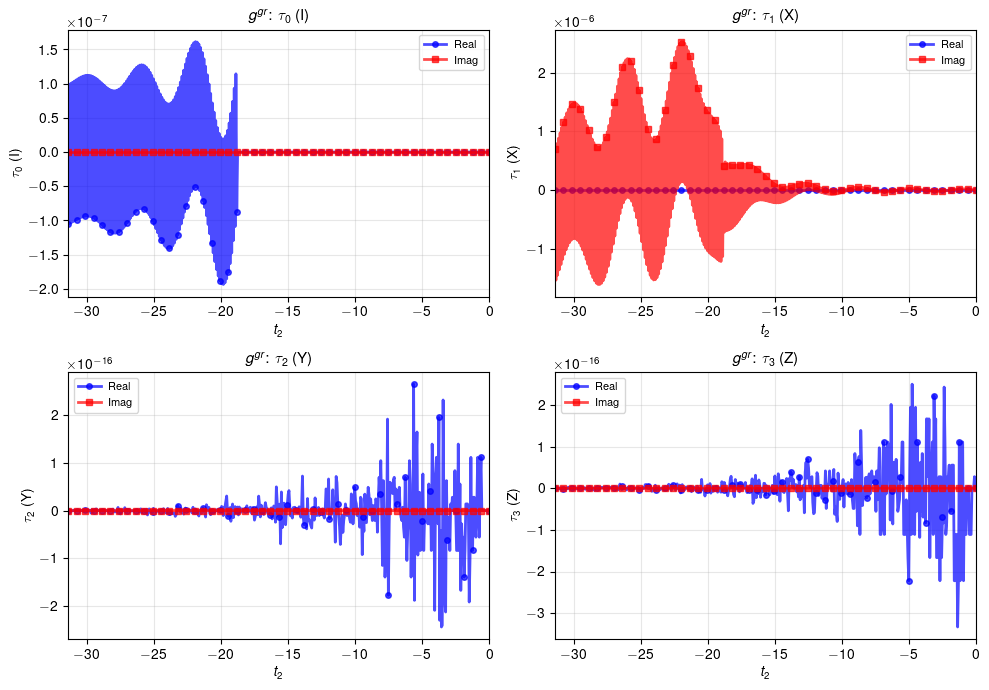


PLOTTING GK NORMALIZATION - Error Values

τ_0 component:
  Plotting range: [-1.0066e-18, 7.3371e-19]
  Mean error: -5.1880e-20
  Std deviation: 3.0693e-19
  Max error: 3.2660e-01

τ_1 component:
  Plotting range: [-2.1494e-04, 9.5379e-02]
  Mean error: 1.8454e-04
  Std deviation: 4.2574e-03
  Max error: 9.5379e-02

τ_2 component:
  Plotting range: [-1.0038e-18, 6.1610e-22]
  Mean error: -1.9960e-21
  Std deviation: 4.4803e-20
  Max error: 4.7184e-16

τ_3 component:
  Plotting range: [-1.0372e-20, 3.9500e-21]
  Mean error: -2.9958e-21
  Std deviation: 2.8822e-21
  Max error: 1.8319e-15



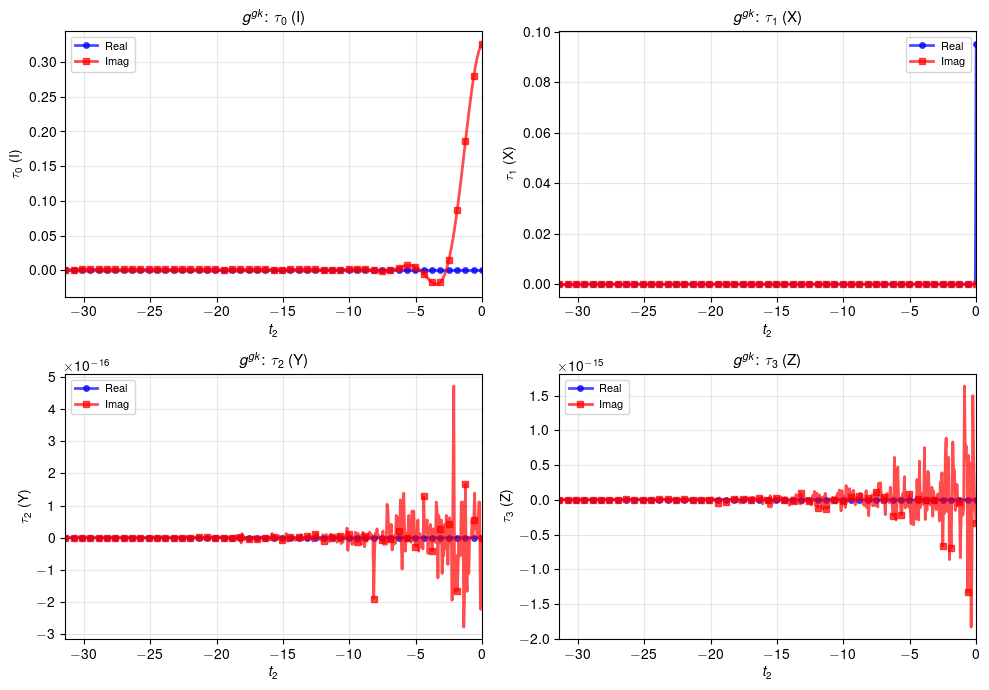

  gr errors per channel:
    τ₀: 1.94e-07
    τ₁: 2.53e-06
    τ₂: 2.64e-16
    τ₃: 3.33e-16
  gr max error: 2.53e-06 (in channel τ₁)

  gk errors per channel:
    τ₀: 3.27e-01
    τ₁: 9.54e-02
    τ₂: 4.72e-16
    τ₃: 1.83e-15
  gk max error: 3.27e-01 (in channel τ₀)


In [ ]:
# Check gr and gk normalization relations
norm_results = da.check_normalizations(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']

print(f"  gr errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gr_max_error'][i]:.2e}")
gr_max_idx = np.argmax(norm_results['gr_max_error'])
print(f"  gr max error: {norm_results['gr_max_error'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gk_max_error'][i]:.2e}")
gk_max_idx = np.argmax(norm_results['gk_max_error'])
print(f"  gk max error: {norm_results['gk_max_error'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")


FDT CHECK - Maximum Error Indices

τ_0 component:
  max_error = 4.4409e-16 at index 466
  error_at_last_element = 2.4177e-19 + 0.0000e+00j

τ_1 component:
  max_error = 5.2736e-16 at index 455
  error_at_last_element = 0.0000e+00 + -5.1455e-19j

τ_2 component:
  max_error = 1.0544e-01 at index 492
  error_at_last_element = 0.0000e+00 + -4.7690e-02j

τ_3 component:
  max_error = 4.2756e-03 at index 0
  error_at_last_element = -1.8190e-18 + 0.0000e+00j



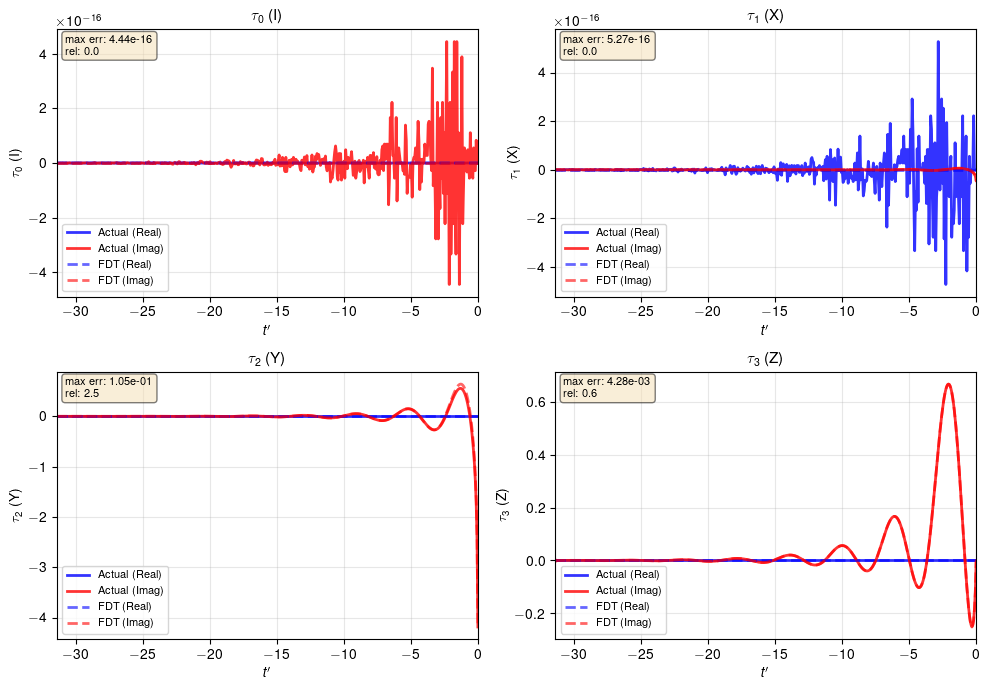


FDT Check Results:
  Errors per channel:
    τ₀: 4.44e-16
    τ₁: 5.27e-16
    τ₂: 1.05e-01
    τ₃: 4.28e-03
  Max error: 1.05e-01 (in channel τ₂)


In [ ]:
# Check fluctuation-dissipation theorem
fdt_results = da.check_fdt(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nFDT Check Results:")
print(f"  Errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {fdt_results['max_error'][i]:.2e}")
max_idx = np.argmax(fdt_results['max_error'])
print(f"  Max error: {fdt_results['max_error'][max_idx]:.2e} (in channel {pauli_names[max_idx]})")

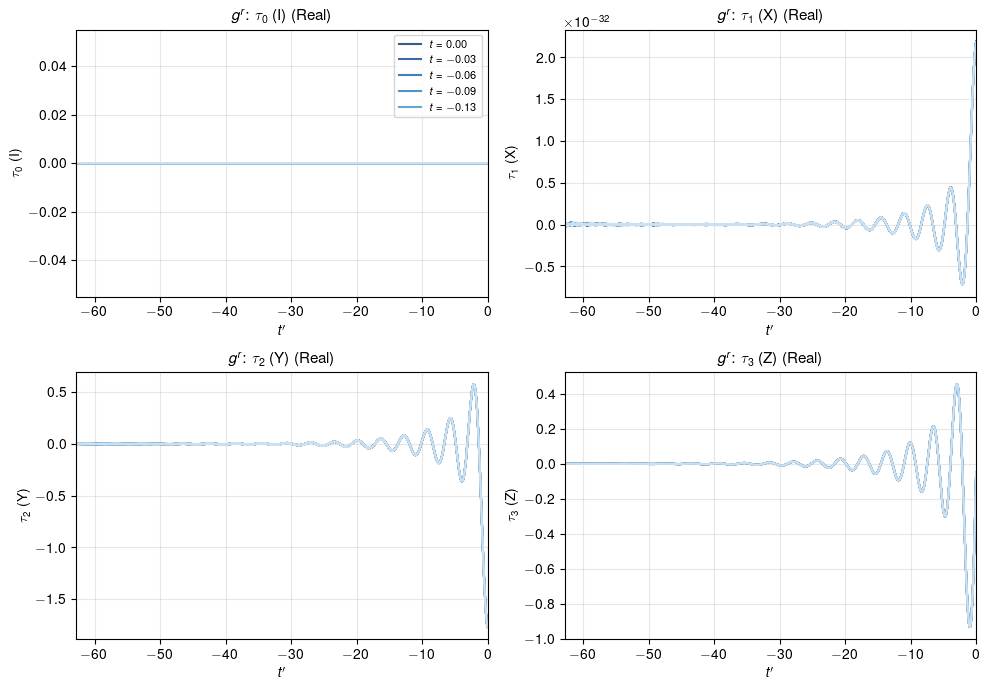

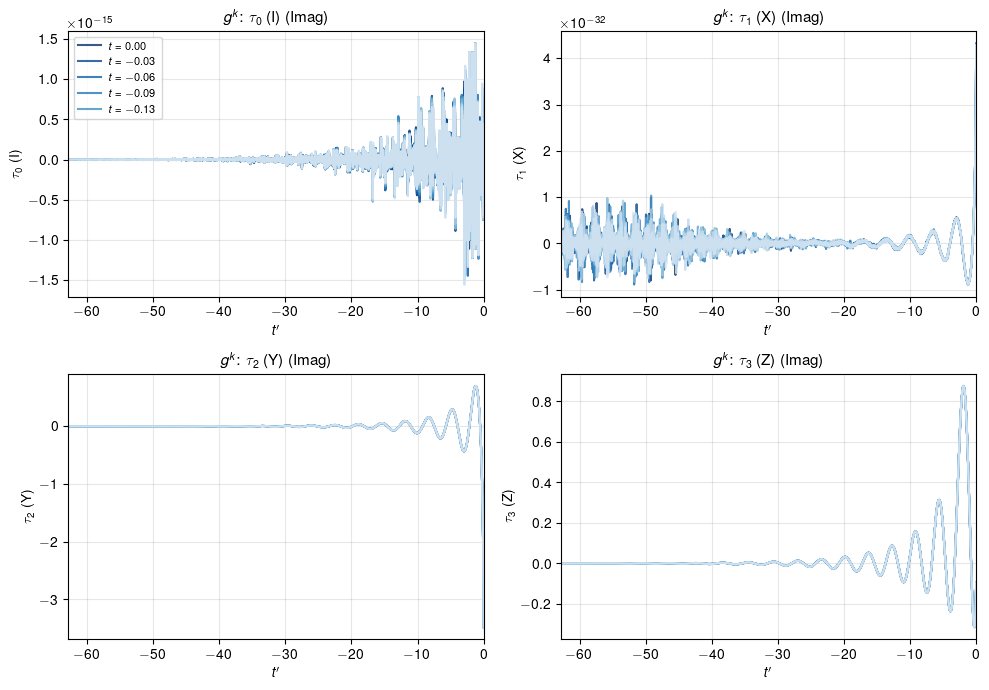


Time-Translation Invariance Results:
  gr max diffs per row: [0.0, np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254), np.float64(1.778040857289254)]
  gr max diff: 1.78e+00 (in row 2 from last)

  gk max diffs per row: [0.0, np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.354402880936259), np.float64(5.363589594660062)]
  gk max diff: 5.36e+00 (in row 10 from last)

  Passed (threshold 1e-08): False


In [ ]:
# Check time-translation invariance (equilibrium test)
tti_results = da.check_time_translational_invariance(check_timestamp, check_job_index,
                                                      num_rows=10, threshold=1e-8, save_plot=False)

print(f"\nTime-Translation Invariance Results:")
print(f"  gr max diffs per row: {tti_results['max_diff_gr']}")
gr_max_idx = np.argmax(tti_results['max_diff_gr'])
print(f"  gr max diff: {tti_results['max_diff_gr'][gr_max_idx]:.2e} (in row {gr_max_idx + 1} from last)")

print(f"\n  gk max diffs per row: {tti_results['max_diff_gk']}")
gk_max_idx = np.argmax(tti_results['max_diff_gk'])
print(f"  gk max diff: {tti_results['max_diff_gk'][gk_max_idx]:.2e} (in row {gk_max_idx + 1} from last)")

print(f"\n  Passed (threshold {tti_results['threshold']:.0e}): {tti_results['passed']}")

# 2. Gap and Current Analysis

In [ ]:
evolution_timestamp = '1782915967'
evolution_job_index = 0
equilibrium_timestamp = '1782220134'


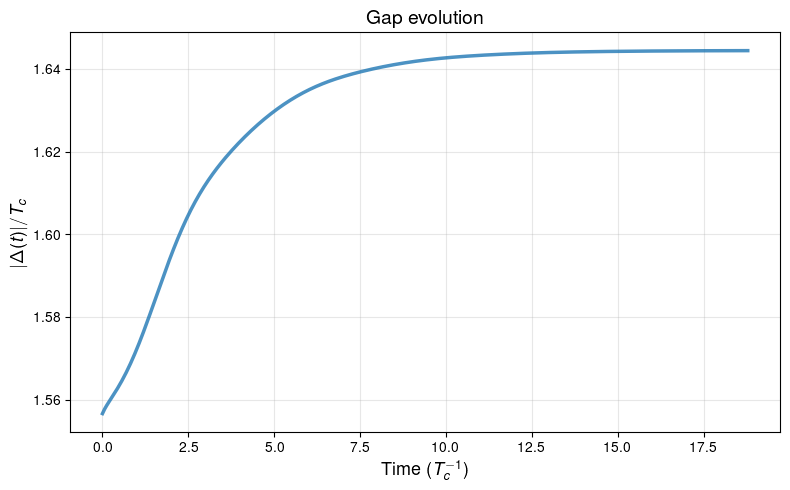

In [ ]:
# Plot gap evolution for this job
da.plot_gap(evolution_timestamp, evolution_job_index, save_plot=False)



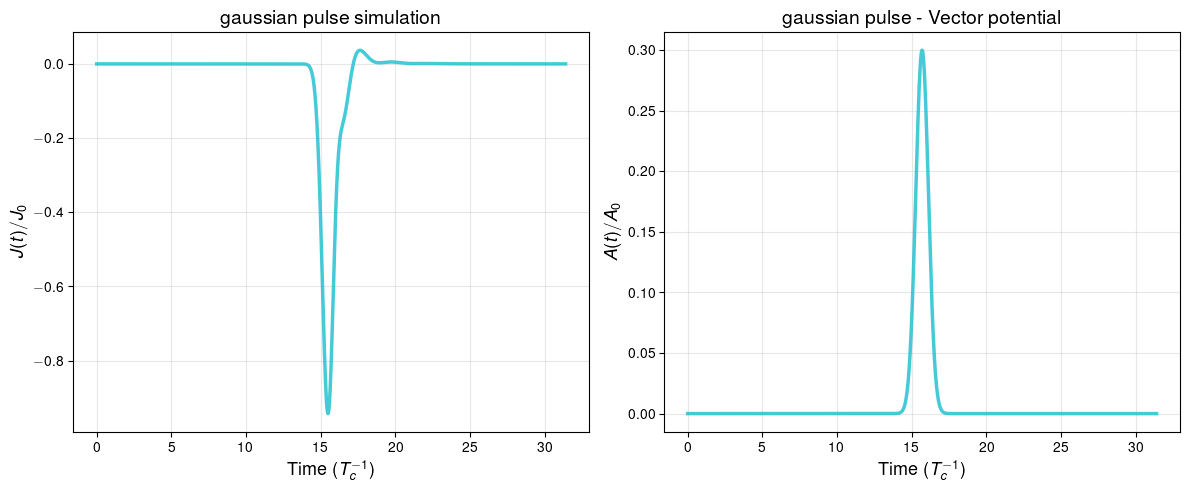

In [ ]:
# Plot current evolution for this job
da.plot_current(evolution_timestamp, evolution_job_index, save_plot=False)



Parameter validation (evolution vs equilibrium):
  eta: 0.2 ✓
  temperature: 0.5 ✓
  critical_temperature: 1 ✓
  Total time duration: 0.000000 ✓

Loading equilibrium sweep data...
Loaded equilibrium data: 20 points from A=0.000 to 0.800

Job 0: Plotting 1500 points
  Gap range: [1.117, 1.402]
  Current range: [-0.811, 0.003]
  A range: [4.062e-13, 3.000e-01]
  Time range: [0.000, 31.395]

Pulse alignment enabled:
  Reference pulse maximum at t = 15.687
  External dataset 'Quasi-equilibrium': t_max = 9.975, shift = +5.712


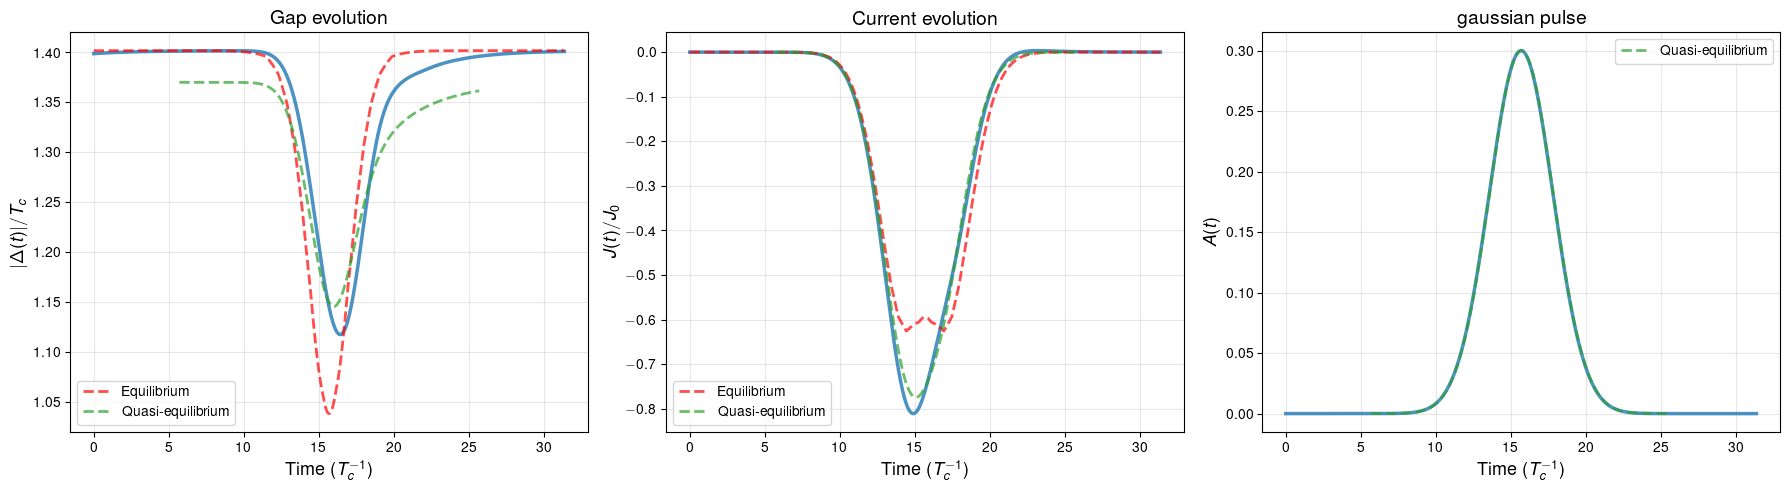

In [ ]:
da.plot_gap_current_combined(
      timestamp=evolution_timestamp,           # Your time evolution run
      job_index=evolution_job_index,                      # Specific job to plot
      equilibrium_timestamp=equilibrium_timestamp,  # Your equilibrium sweep run
      n_average=100,                    # Average last 100 timesteps for equilibrium
      save_plot=False,
      times_external = jons_time_pts,
      gaps_external = jons_gaps[evolution_job_index],
      currents_external = jons_total_current[evolution_job_index],
      A_external = jons_vector_potentials[evolution_job_index],
      labels_external = 'Quasi-equilibrium',
      align_pulses = True              # Save to Figures/
  )


# 3. Parameter Sweep Analysis

Run this section to compare equilibrated gap/current across multiple timestamps.

In [ ]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1782219875']  # Add more timestamps as needed: ['ts1', 'ts2', ...]
# '1782219875' -- eta = 0.1; '1782219990' -- eta = 0.2

# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'temperature'

# Number of final timesteps to average for equilibration
n_average = 50

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: temperature
Timestamps to analyze: ['1782219875']
Averaging last 50 timesteps


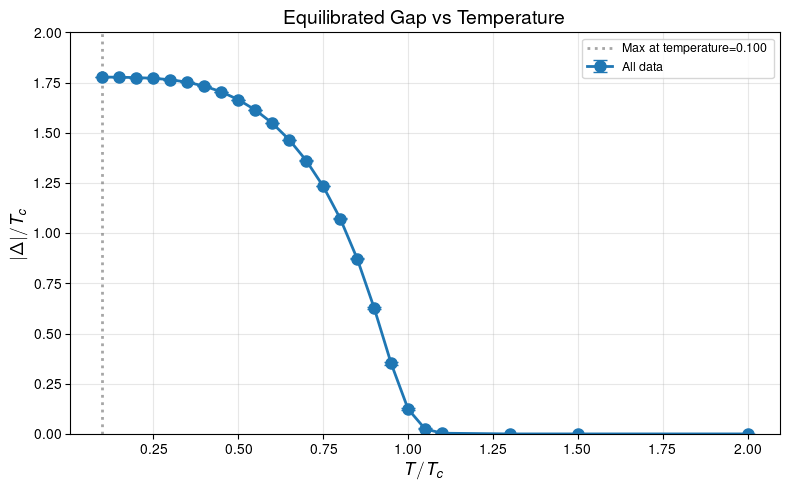


Gap Sweep Results:
  Parameter values: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.3  1.5  2.  ]
  Gap means: [1.77801873e+00-2.18953963e-32j 1.77707088e+00-1.44451121e-32j
 1.77533250e+00-2.46046605e-32j 1.77178238e+00-1.12117504e-32j
 1.76476553e+00-2.37625091e-32j 1.75239955e+00-1.30958212e-32j
 1.73286136e+00-2.23266297e-32j 1.70444054e+00-1.93484867e-32j
 1.66545637e+00-2.09285435e-32j 1.61411445e+00-1.38127016e-32j
 1.54832706e+00-1.46553526e-32j 1.46547996e+00-1.31381611e-32j
 1.36212050e+00-1.46028500e-32j 1.23352933e+00-1.64795160e-32j
 1.07325315e+00-1.64119041e-32j 8.73216056e-01-1.01641401e-32j
 6.27538195e-01-8.40441595e-33j 3.51550507e-01-2.68717989e-33j
 1.23570088e-01-1.21916089e-33j 2.48834540e-02-2.29551829e-34j
 3.56512552e-03+6.88760414e-36j 1.62155990e-06+3.92916019e-36j
 1.38276260e-07+5.17421268e-36j 8.41171766e-08-2.98225515e-38j]
  Gap errors: [1.42604938e-05 1.41582947e-05 1.40392225e-05 1.39507

In [ ]:
# Plot equilibrated gap vs parameter
gap_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps, 
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, combine_timestamps = True,
    #x_external = eq_T, y_external = eq_gap_mag_T
)


print(f"\nGap Sweep Results:")
print(f"  Parameter values: {gap_sweep_results['parameter_values']}")
print(f"  Gap means: {gap_sweep_results['gap_means']}")
print(f"  Gap errors: {gap_sweep_results['gap_errors']}")
print(f"\nMaximum Gap:")
print(f"  Max |Δ| = {gap_sweep_results['max_gap']:.4f}")
print(f"  At {sweep_parameter} = {gap_sweep_results['max_parameter']:.4f}")

In [ ]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1782982330']  # Add more timestamps as needed: ['ts1', 'ts2', ...]
#['1781703060', '1781703037', '1781702934']
# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'vector_potential'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: vector_potential
Timestamps to analyze: ['1782982330']
Averaging last 100 timesteps


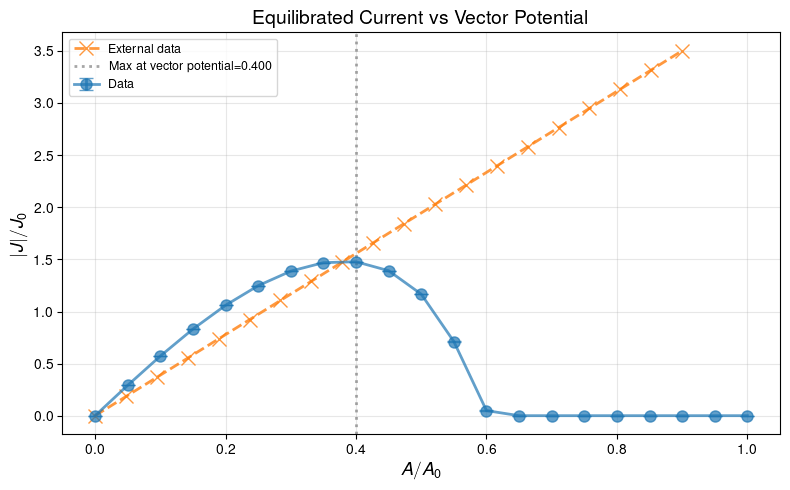

In [ ]:
# Plot equilibrated current vs parameter

current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A], y_external = [eq_A * np.pi * 1.4 * np.tanh(1.4/2/0.5)]
)
#* added 1/2 factor for comparison since original current heory was wrong so to rescale. -- fixed in new version 

#print(np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)/2)
#print(np.max(eq_current_A))

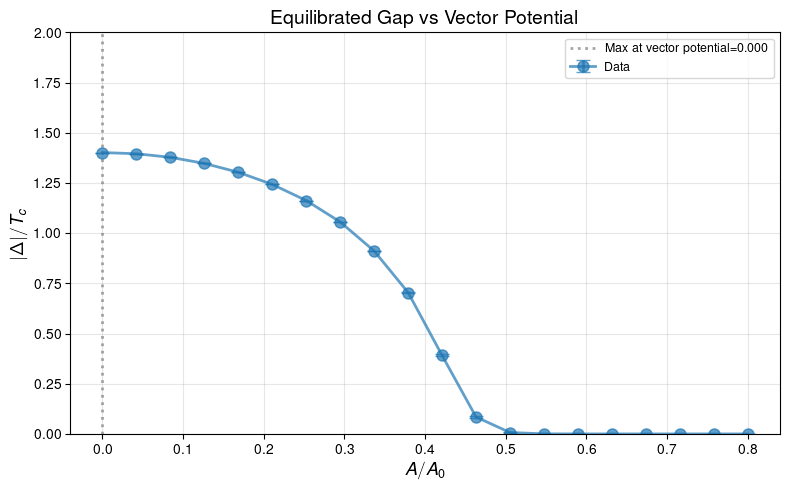

In [ ]:
x_jon = [0.        , 0.02586207 ,0.05172414 ,0.07758621 ,0.10344828, 0.12931034,
 0.15517241, 0.18103448, 0.20689655, 0.23275862, 0.25862069, 0.28448276,
 0.31034483, 0.3362069 , 0.36206897, 0.38793103, 0.4137931,  0.43965517,
 0.46551724, 0.49137931, 0.51724138, 0.54310345, 0.56896552, 0.59482759,
 0.62068966, 0.64655172, 0.67241379, 0.69827586, 0.72413793, 0.75]
y_jon = [1.51163408e+00, 1.51027885e+00, 1.50620005e+00, 1.49935768e+00,
 1.48968270e+00, 1.47707321e+00, 1.46138854e+00, 1.44244072e+00,
 1.41998222e+00, 1.39368837e+00, 1.36313217e+00, 1.32774717e+00,
 1.28677174e+00, 1.23916228e+00, 1.18345224e+00, 1.11750939e+00,
 1.03808374e+00, 9.39867391e-01, 8.13187470e-01, 6.36954560e-01,
 3.67131713e-01, 9.64004201e-02, 1.35302658e-02, 1.55015802e-03,
 1.64641301e-04, 1.68474568e-05, 1.68997743e-06, 1.67848029e-07,
 1.66168484e-08, 9.13836357e-09]

# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False,
    #x_external = [eq_A,x_jon], y_external = [eq_gap_mag_A,y_jon]
)




# 4. Quasi-particle evolution dynamics 

In [ ]:
twodplot_timestamp = '1782724196' # 1782316004
twodplot_job_index = 0

In [ ]:
da.plot_two_time_pauli_components(
    timestamp=twodplot_timestamp, job_index=twodplot_job_index, green_function_type='gk')  # Your timestamp)

Green's function tensor shape: (2, 2, 1, 2, 1501, 1501)


ValueError: Expected 4D tensor, got 6D with shape (2, 2, 1, 2, 1501, 1501)


Off-diagonal Analysis: $g^R$ Pauli component τ_3
Timestamp: 1782724196, Job: 0
Real part: min=2.142003e-04, max=2.142003e-04
Imag part: min=-1.468573e-21, max=-1.468573e-21
Edge values: g(τ_min)=2.142003e-04, g(τ_max)=2.142003e-04
Center value: g(0)=2.142003e-04

Parity analysis:
  Even component norm: 2.142003e-04 (100.00% of total)
  Odd component norm:  0.000000e+00 (0.00% of total)
  Dominant parity: EVEN

Symmetry check at specific points:


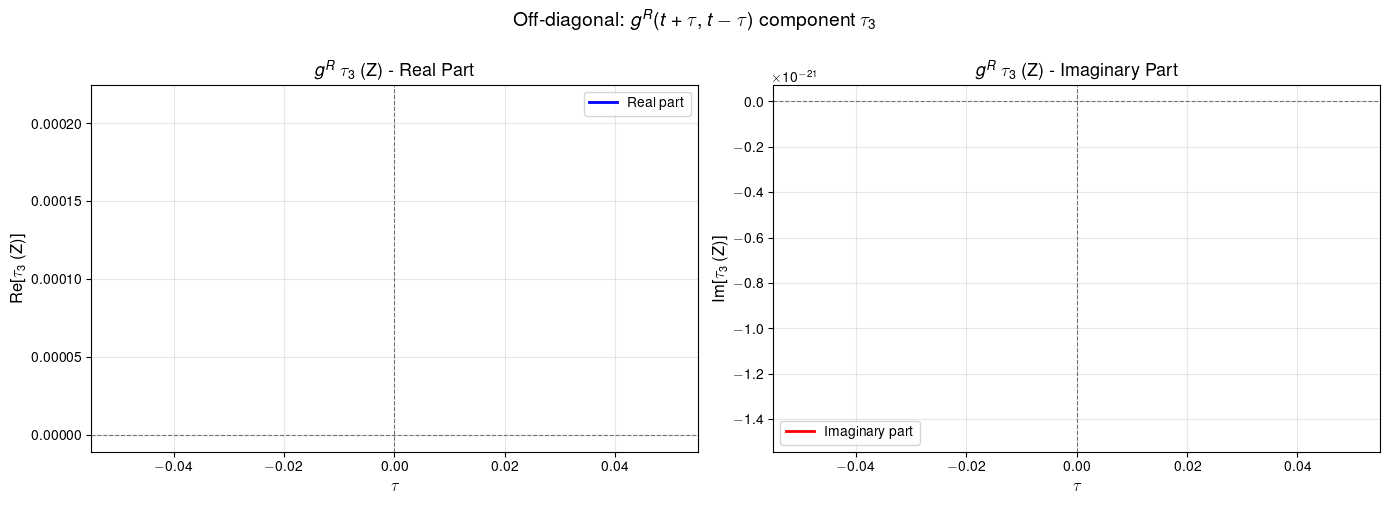

{'tau_grid': array([0.]),
 'g_tau': array([0.0002142-1.46857269e-21j]),
 'symmetry_test': {'even_norm': np.float64(0.00021420028154418546),
  'odd_norm': np.float64(0.0),
  'even_fraction': np.float64(1.0),
  'odd_fraction': np.float64(0.0),
  'even_part': array([0.0002142-1.46857269e-21j]),
  'odd_part': array([0.+0.j])}}

In [ ]:
da.plot_offdiagonal_matrix_element(
    timestamp=twodplot_timestamp, job_index=twodplot_job_index, green_function_type='gr', pauli_index = 3)

In [ ]:
qp_timestamp = '1782724196' # '' 1782462195
qp_job_index = 0     


Energy-Time Plot (timestamp=1782724196, job_index=0):
  Green's function type: g^f
  Pauli components: (0, 3)
  Total time slices available: 20
  Plotting every 1 slice(s): 20 lines
  Time range (center times): [-15.71, -15.31]
  (Offset by 750 timesteps = 15.71 time units)



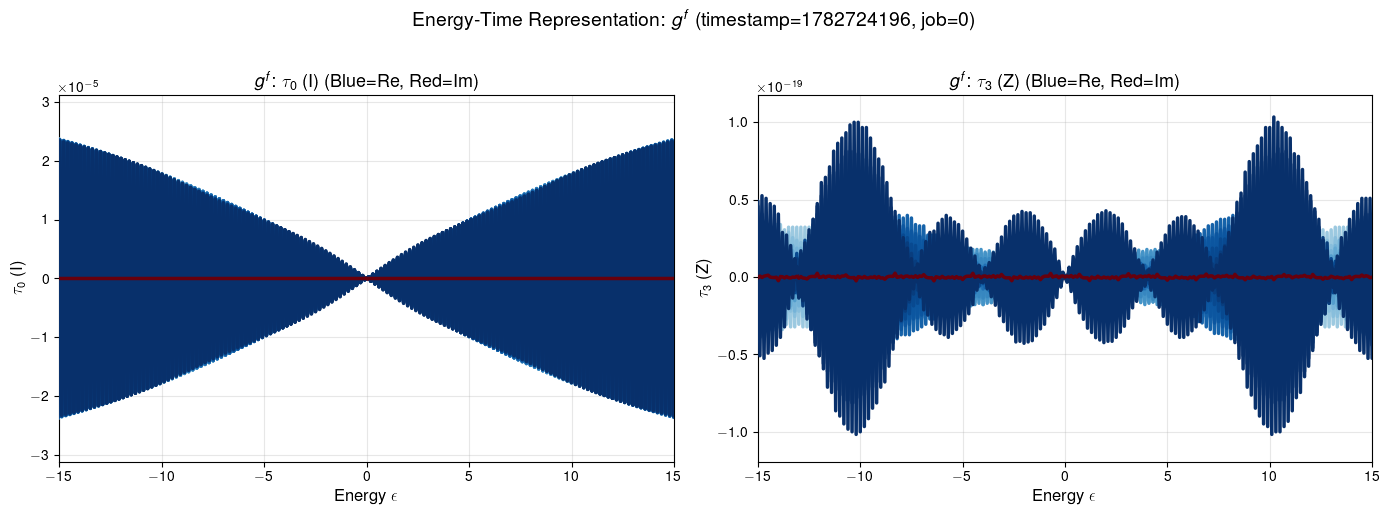

{'energy_grid': array([-74.95003331, -74.85009993, -74.75016656, ...,  74.75016656,
         74.85009993,  74.95003331], shape=(1501,)),
 'time_indices': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 'time_values': array([0.        , 0.02094395, 0.0418879 , 0.06283185, 0.0837758 ,
        0.10471976, 0.12566371, 0.14660766, 0.16755161, 0.18849556,
        0.20943951, 0.23038346, 0.25132741, 0.27227136, 0.29321531,
        0.31415927, 0.33510322, 0.35604717, 0.37699112, 0.39793507]),
 'data': [{'energy_grid': array([-74.95003331, -74.85009993, -74.75016656, ...,  74.75016656,
           74.85009993,  74.95003331], shape=(1501,)),
   'g_energy': <nambu_keldysh_class.NambuKeldyshTensor at 0x7f73553c1a30>},
  {'energy_grid': array([-74.95003331, -74.85009993, -74.75016656, ...,  74.75016656,
           74.85009993,  74.95003331], shape=(1501,)),
   'g_energy': <nambu_keldysh_class.NambuKeldyshTensor at 0x7f73553c2ed0>},
  {'energy_grid': 

In [ ]:
da.plot_energy_time_representation(
    timestamp=qp_timestamp,  # Your timestamp
    job_index=qp_job_index,    # Your job index
    green_function_type='f',
    #pauli_components=(2, 3),  # tau_0 and tau_3
    plot_every = 1,             # Plot every 5th time sl
    save_plot=False, 
    #markers = False,
    plot_eq = False
    )


In [ ]:

result = da.plot_energy_time_representation_slider(
      timestamp=qp_timestamp,
      job_index=qp_job_index,
      green_function_type='gr',
      #pauli_components=(2, 3),
      xlim=(-10, 10),
      plot_eq=True
  )



NameError: name 'np' is not defined

# 5. Linear response -- Conductivity 

In [ ]:
omegas, sigmas = utils.compute_equilibrium_conductivity(timestamp = '1782220965', job_index = 0)
print(omegas, sigmas)
timestamp = '1782220965'  # Your timestamp # eta = 0.2 ts '1782220965' eta = 0.1 ts = '1782848090'
job_index = 1  # Your job index


Computing equilibrium Green's functions...
  Gap: 1.3987, Temperature: 0.5000, eta: 0.2000

Epsilon grid info:
  Size: 15010
  Range: [-150.0000, 149.9800]
  Spacing: 0.019987

Computing conductivity integral...
  Omega range: [0, 13.99] (10*gap)
  Omega points: 700, Epsilon points: 15010


Computing σ(ω):  65%|██████▌   | 456/700 [01:38<03:00,  1.35it/s]

Max |A(t)| = 4.995e-02

Time-domain boundary values:
  A(t_start) = 0.000e+00+0.000e+00j, A(t_end) = 0.000e+00+0.000e+00j
  j(t_start) = 0.000e+00+0.000e+00j, j(t_end) = 5.011e-07+2.164e-38j
  Max |A(t)| = 4.995e-02
  Max |j(t)| = 1.840e-01

Conductivity Extraction (timestamp=1782220965, job_index=1):
  Time step (dt): 0.020944
  Total duration (T_total): 31.395
  Number of time points: 1500
  Frequency resolution (Δω): 0.200000
  Nyquist frequency (ω_max): 150.000
  Equilibrium gap (Δ₀): 1.398715
  Max |A(ω)|: 1.461e+00
  Threshold: 1.000e-02
  Valid frequency range: [-12.800, 12.800]
  Number of valid frequency points: 128/1500



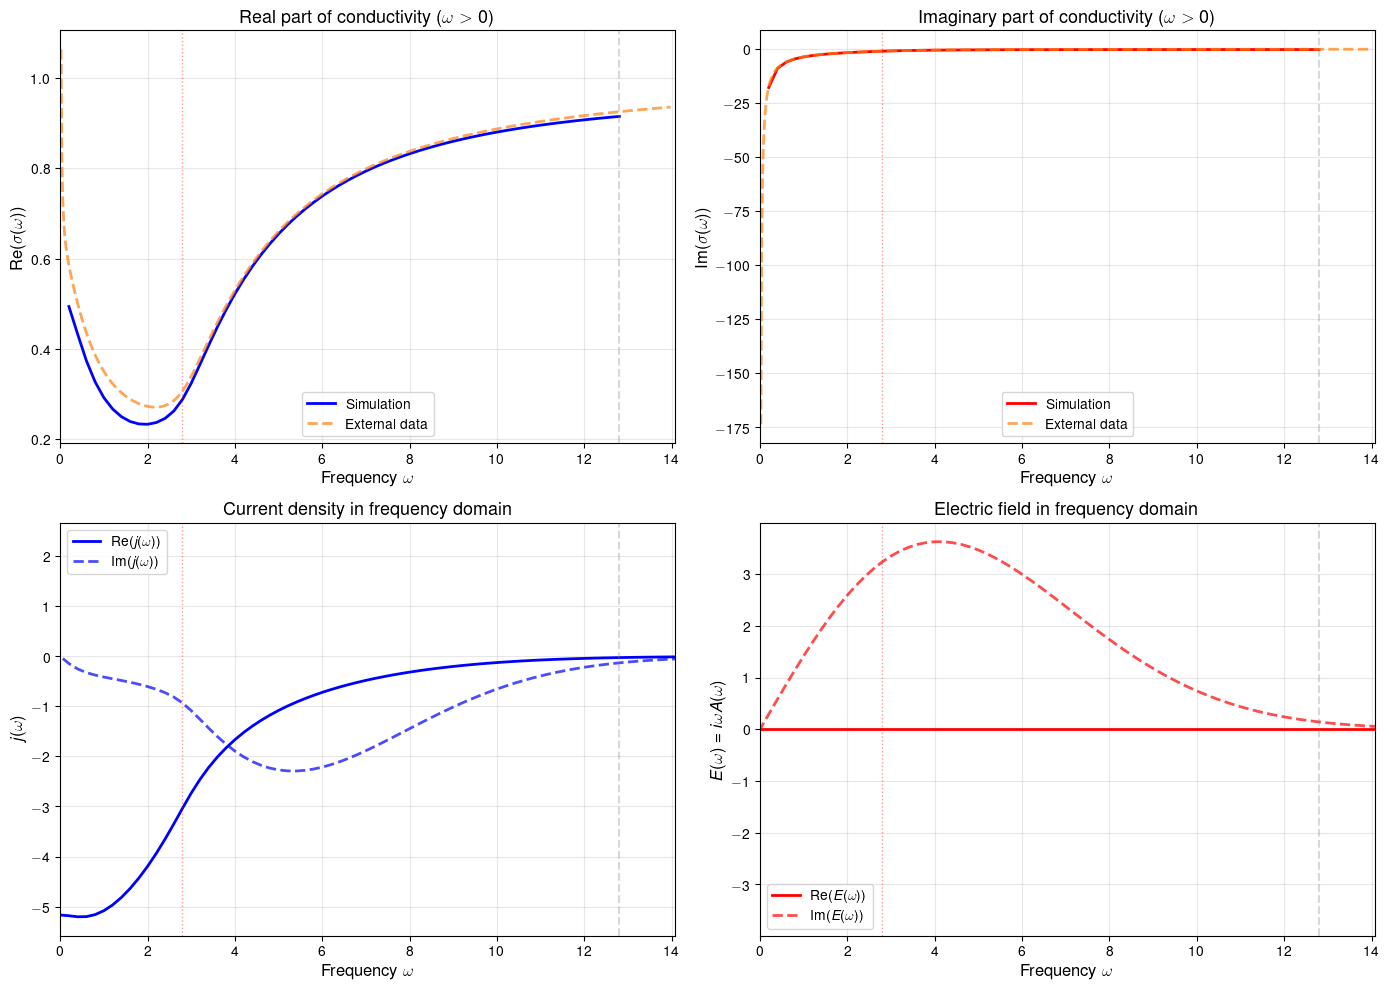

In [ ]:

result = da.extract_conductivity(
    timestamp=timestamp,
    job_index=job_index,
    threshold=1e-2,  # Filter out noise where |A(ω)| is small
    save_plot=False,  # Save the plot    
    save_dir=None,
    omega_external = omegas, sigma_re_external = np.real(sigmas),
    sigma_im_external = np.imag(sigmas)
)


# Current Kernel

In [ ]:
 #'1782292287' eta = 0.1  eta = 0.2  '1782220134'

kernel_ts = '1782292287'
da.get_current_kernel(kernel_ts, save_plot=False, job_indices = [0,4,8,15])

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2,2001)->(2,newaxis,2001,newaxis,newaxis,2) (2,2,2,2001,2001)->(2,2,2001,2001,2) 

# Error scaling analysis with $\delta t$ 


Comparing gap sweeps across 6 timestamps

Loading timestamp 1/6: 1782196299
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.01571$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.563165]

Loading timestamp 2/6: 1782196288
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.01795$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.566408]

Loading timestamp 3/6: 1782196259
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.02513$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.576554]

Loading timestamp 4/6: 1782196253
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.02094$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.570689]

Loading timestamp 5/6: 1782196249
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.03142$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.585465]

Loading timestamp 6/6: 178219624

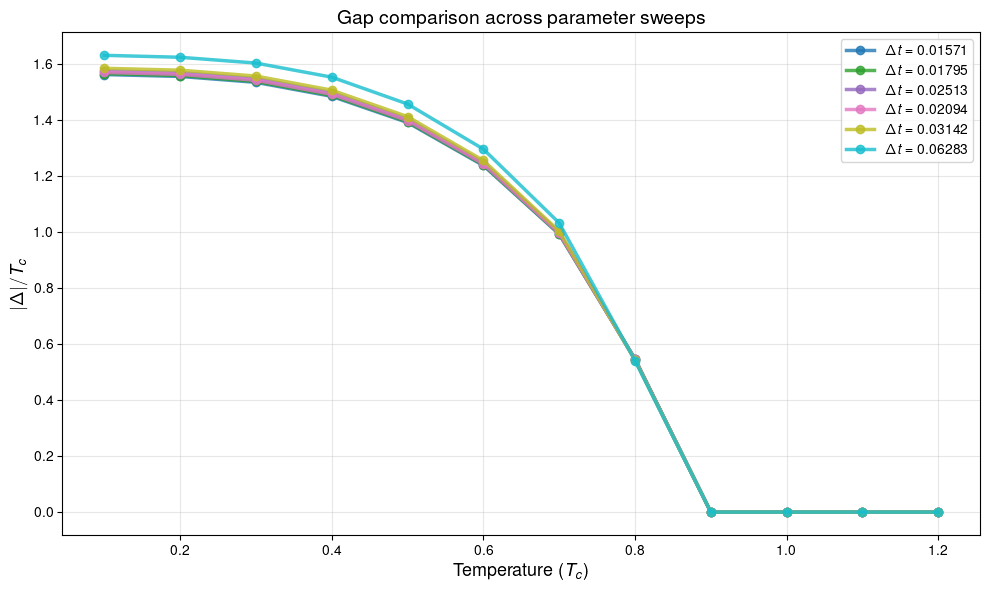

{'fig': <Figure size 1000x600 with 1 Axes>,
 'ax': <Axes: title={'center': 'Gap comparison across parameter sweeps'}, xlabel='Temperature ($T_c$)', ylabel='$|\\Delta| / T_c$'>,
 'data': [{'timestamp': '1782196299',
   'sweep_values': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2]),
   'gap_values': array([1.56316507e+00, 1.55636307e+00, 1.53533936e+00, 1.48534040e+00,
          1.39193570e+00, 1.23826317e+00, 9.93067700e-01, 5.47209917e-01,
          1.70658702e-06, 2.87525852e-12, 2.19980849e-13, 1.36384299e-16]),
   'label': '$\\Delta t = 0.01571$',
   'T_c': 1},
  {'timestamp': '1782196288',
   'sweep_values': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2]),
   'gap_values': array([1.56640845e+00, 1.55955885e+00, 1.53851751e+00, 1.48842582e+00,
          1.39478602e+00, 1.24060731e+00, 9.94271810e-01, 5.46621933e-01,
          1.76066557e-06, 9.88366696e-13, 1.97906661e-13, 4.60368547e-17]),
   'label': '$\\Delta t = 0.01795$',
   'T_c': 1},
 

In [ ]:
da.compare_gap_across_timestamps(
      timestamps=['1782196299', '1782196288', '1782196259', '1782196253', '1782196249', '1782196242'],
      sweep_parameter='system_parameters.temperature',
      label_parameter='dt')

# Plotting multiple gap evolutions while sweeping driving field

## Sweeping FWHM $A = 0.3$


Plotting gap evolution for 10 jobs from timestamp: 1782221046

Loading job 0...
Loading job 1...
Loading job 2...
Loading job 3...
Loading job 4...
Loading job 5...
Loading job 6...
Loading job 7...
Loading job 8...
Loading job 9...

Detected varying parameters:
  field_params.FWHM: [np.float64(5.0), np.float64(4.555555555555555), np.float64(4.111111111111111), np.float64(3.666666666666667), np.float64(3.2222222222222223), np.float64(2.7777777777777777), np.float64(2.3333333333333335), np.float64(1.8888888888888893), np.float64(1.4444444444444446), np.float64(1.0)]


/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


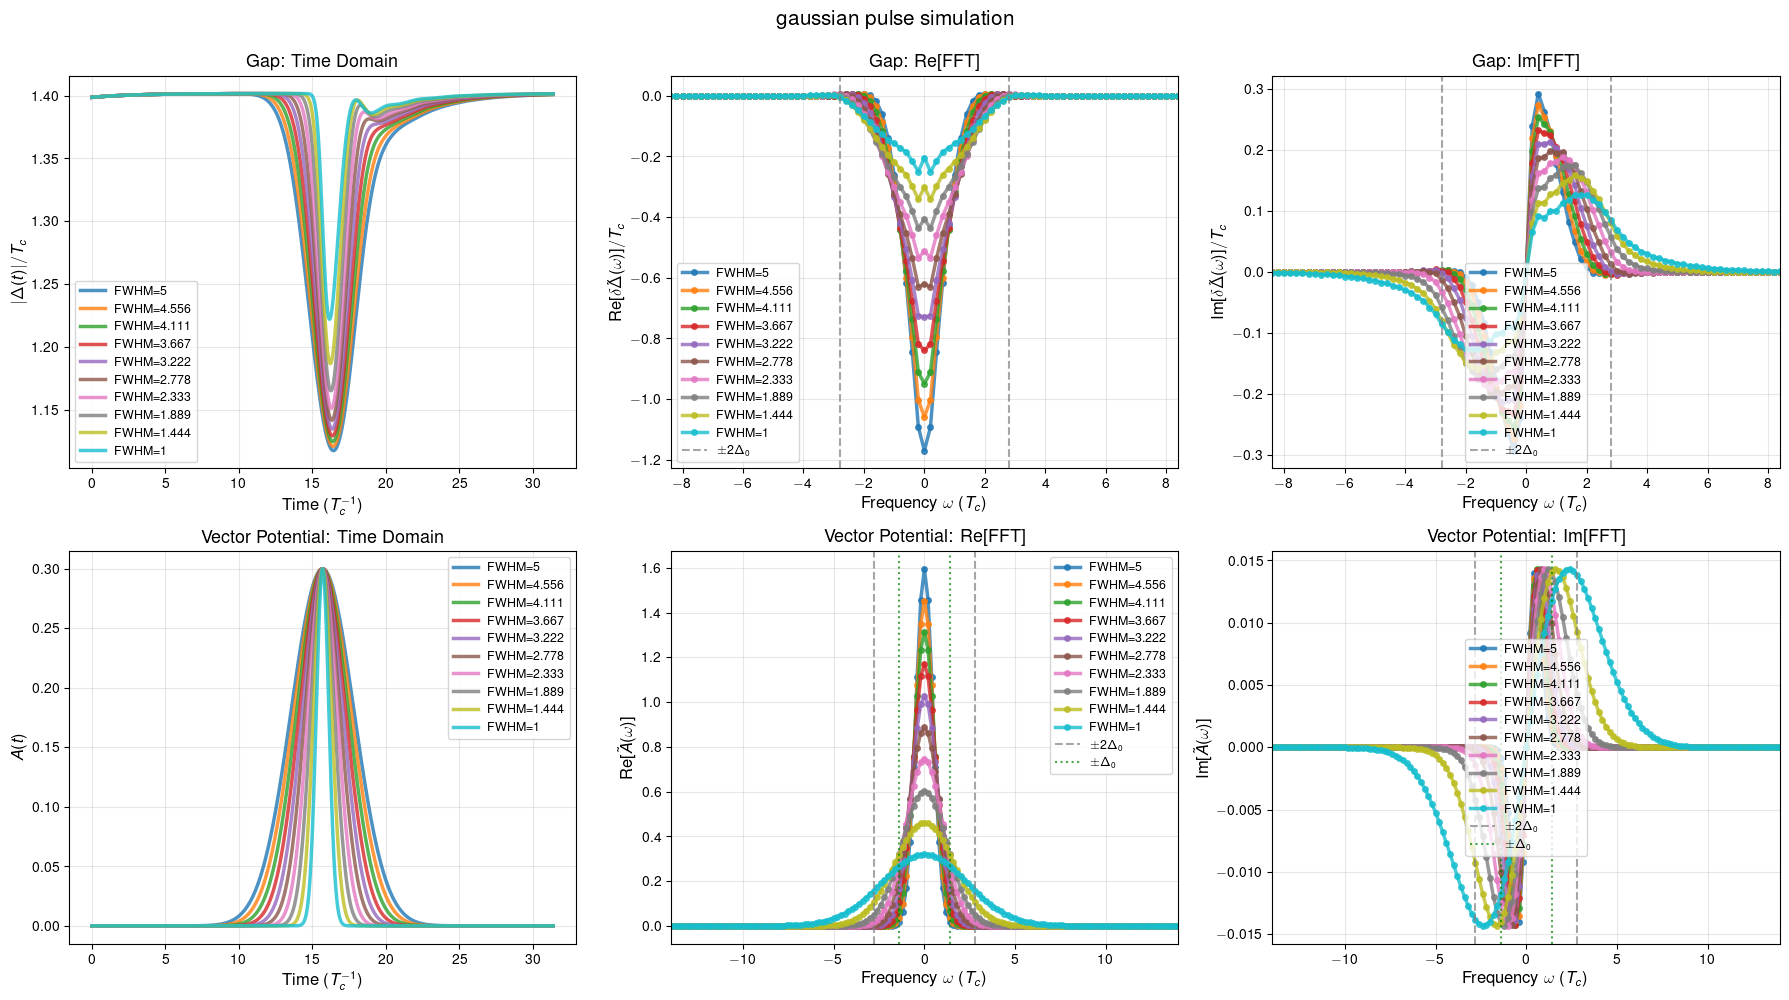

In [8]:
As, gaps, fig, axes = da.plot_gap_evolution_multi_jobs('1782221046', save_plot=False)
#np.save('simulation_data.npy',[As,gaps])



Plotting current evolution for 10 jobs from timestamp: 1782221046

Loading job 0...
Loading job 1...
Loading job 2...
Loading job 3...
Loading job 4...
Loading job 5...
Loading job 6...
Loading job 7...
Loading job 8...
Loading job 9...

Detected varying parameters:
  field_params.FWHM: [np.float64(5.0), np.float64(4.555555555555555), np.float64(4.111111111111111), np.float64(3.666666666666667), np.float64(3.2222222222222223), np.float64(2.7777777777777777), np.float64(2.3333333333333335), np.float64(1.8888888888888893), np.float64(1.4444444444444446), np.float64(1.0)]


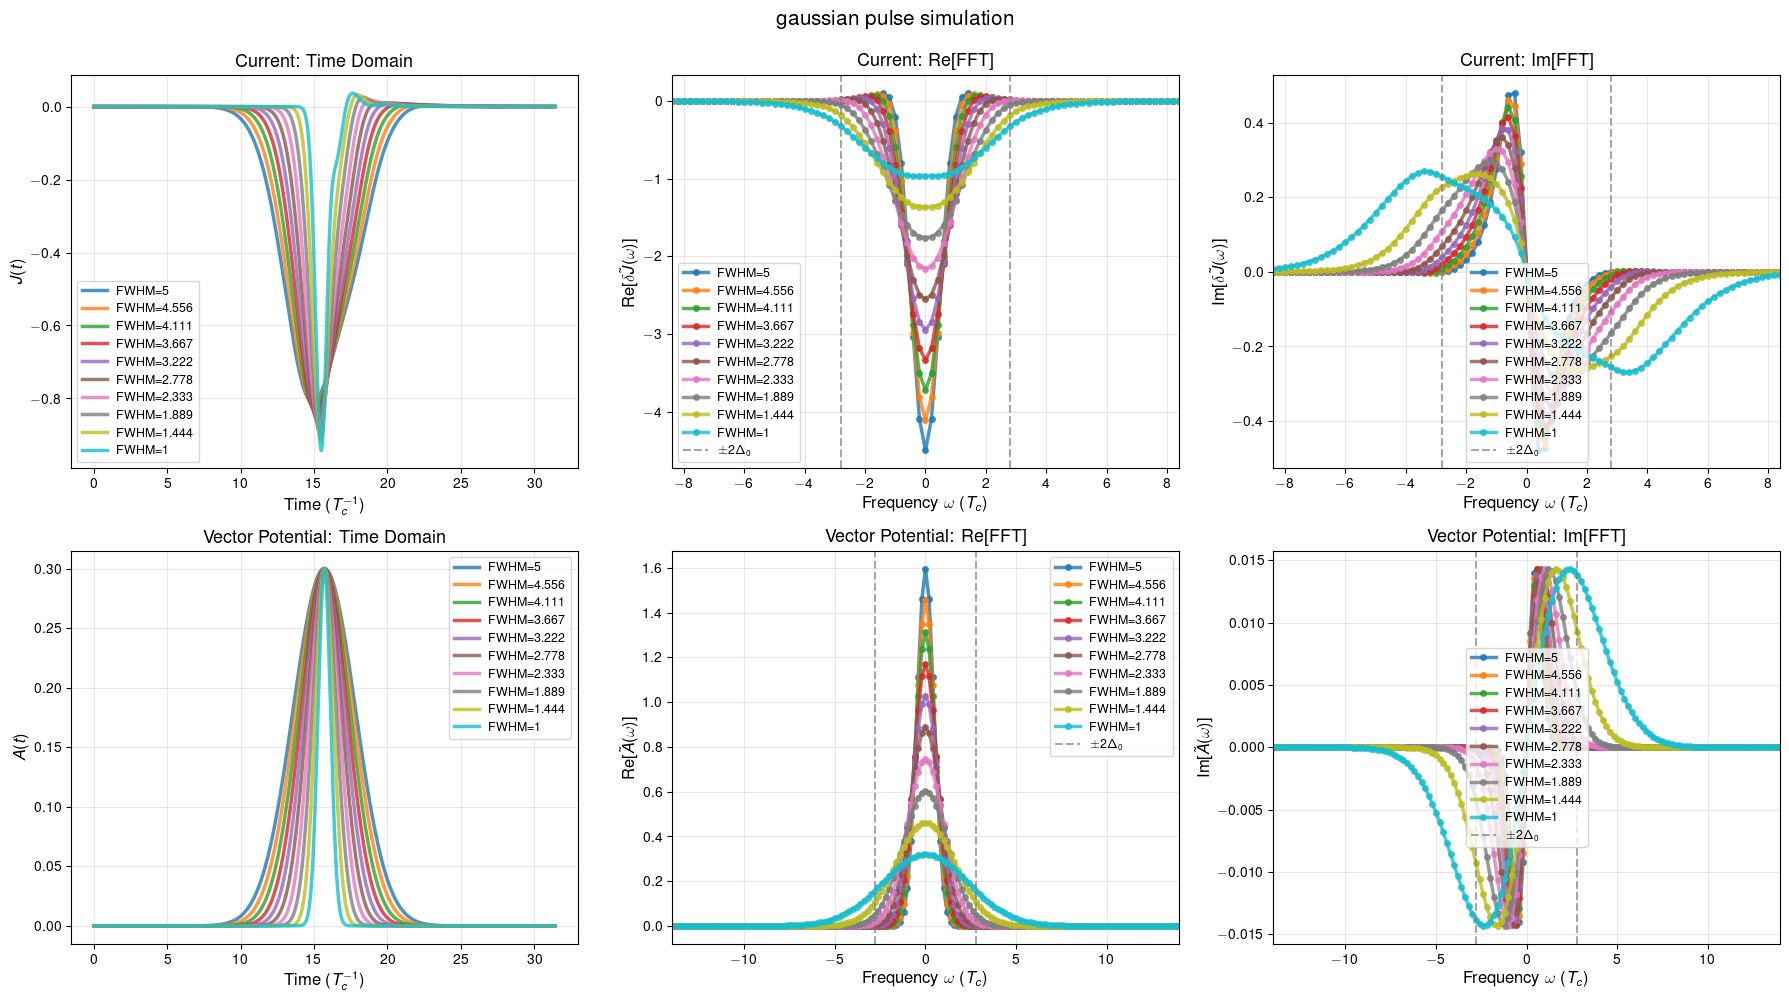

In [9]:
As, js, fig, axes = da.plot_current_evolution_multi_jobs('1782221046',save_plot=False)


In [ ]:
da.identify_sweep_parameters('1782221209')


IDENTIFYING SWEEP PARAMETERS FOR TIMESTAMP: 1782221209

Loading 100 jobs...



KeyboardInterrupt: 

## Width and strength sweeps

[ 4 24 44 64 84]
[81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]

Plotting gap evolution for 7 jobs from timestamp: 1782221209

Loading job 0...
Loading job 0...
Loading job 20...
Loading job 20...
Loading job 40...
Loading job 40...
Loading job 60...

Detected varying parameters:
  field_params.FWHM: [np.float64(0.1), np.float64(0.1), np.float64(0.575), np.float64(0.575), np.float64(1.05), np.float64(1.05), np.float64(1.525)]


/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


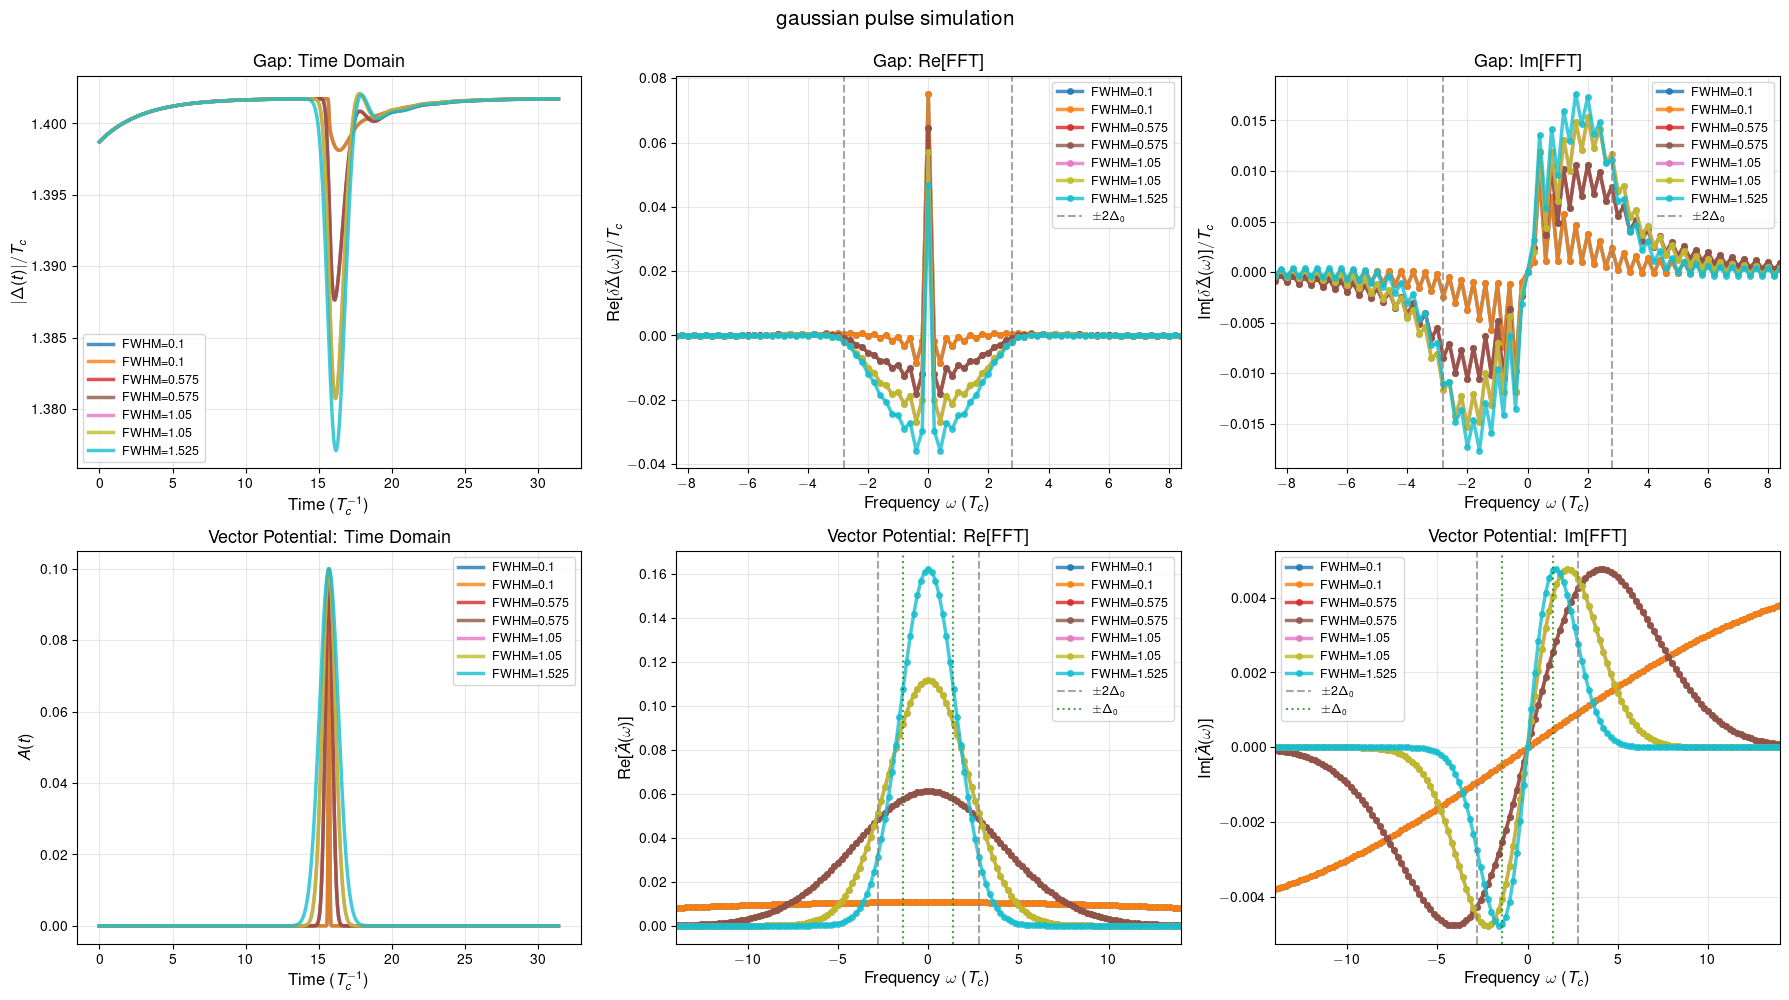

In [ ]:
amplitude_index = 3
width_index = 4

job_list_width = np.arange(1,100,20) + amplitude_index
job_list_amplitude = np.arange(1,20,1) + 20 * (width_index)
job_indices = np.linspace(0, 3, 7).astype(int) * 20 + 0

print(job_list_width)
print(job_list_amplitude)
As, gaps, fig, axes = da.plot_gap_evolution_multi_jobs('1782221209', job_indices = job_indices,save_plot=False)


[ 4 24 44 64 84]
[81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99]

Plotting gap evolution for 19 jobs from timestamp: 1782221209

Loading job 81...
Loading job 82...
Loading job 83...
Loading job 84...
Loading job 85...
Loading job 86...
Loading job 87...
Loading job 88...
Loading job 89...
Loading job 90...
Loading job 91...
Loading job 92...
Loading job 93...
Loading job 94...
Loading job 95...
Loading job 96...
Loading job 97...
Loading job 98...
Loading job 99...

Detected varying parameters:
  field_params.amplitude: [np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.7999999999999999), np.float64(0.8999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.5999999999999999), np.float64(1.7), np.float64(1.8), np.float64(1.9), np.float64(2.0)]


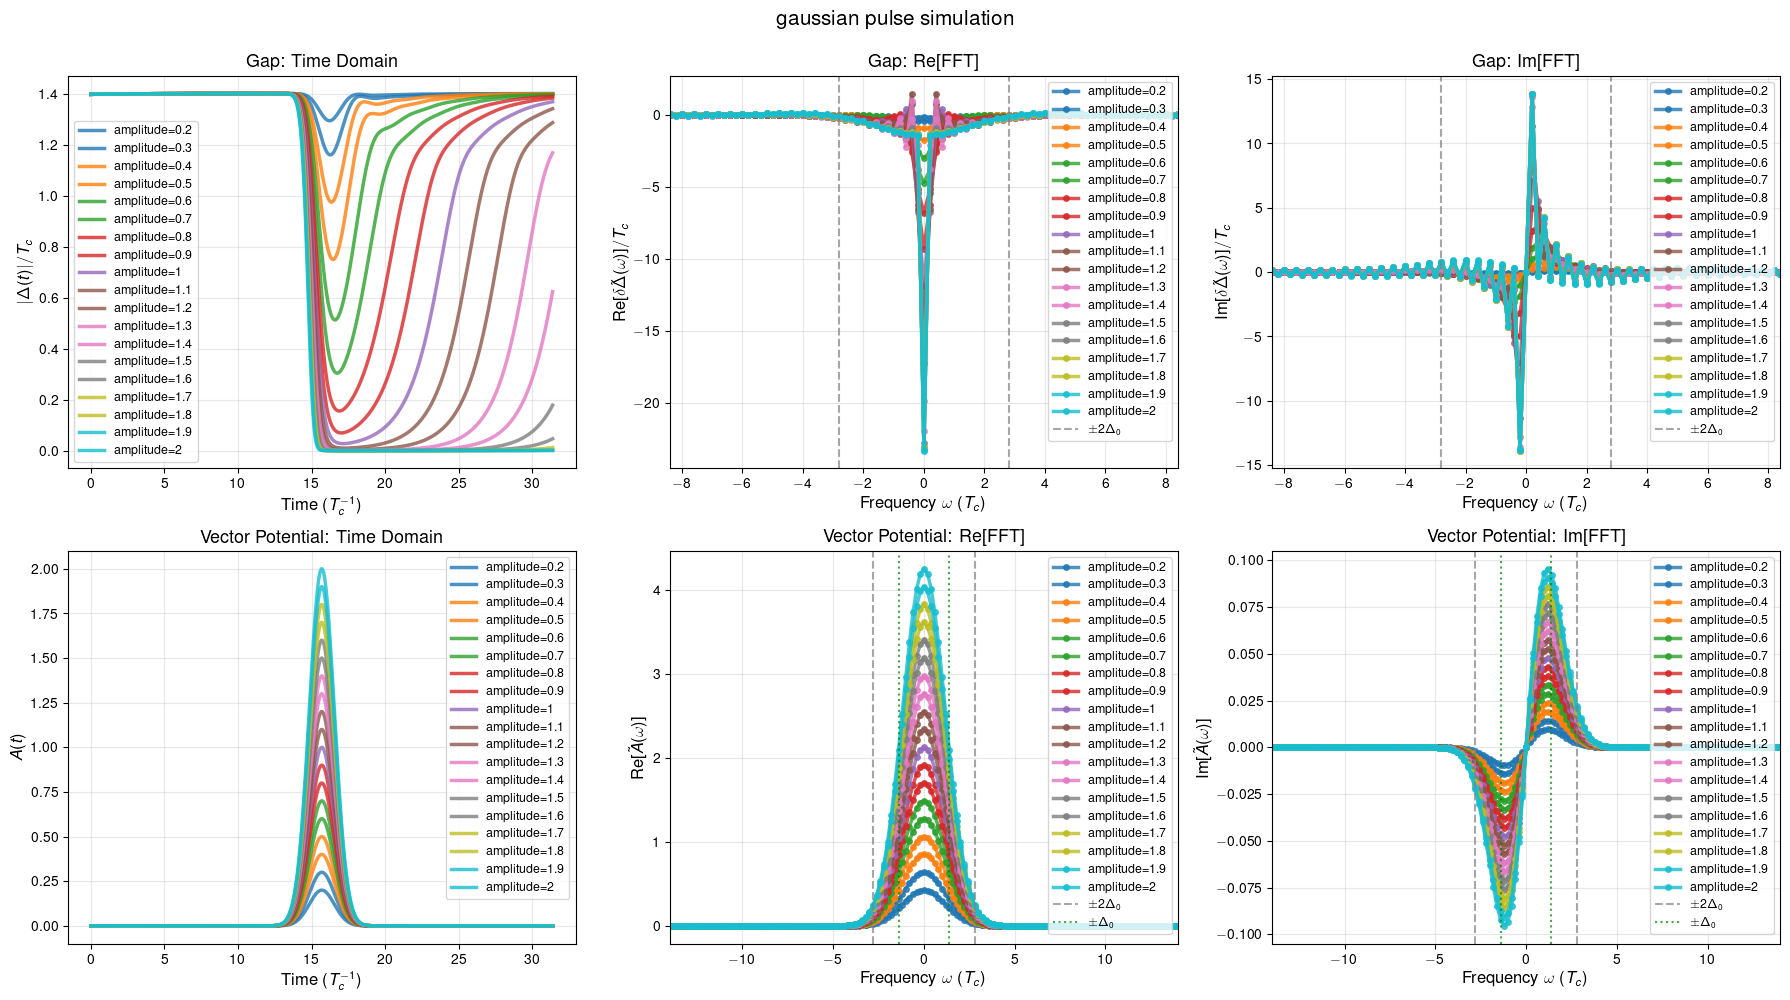

In [11]:
amplitude_index = 3
width_index = 4

job_list_width = np.arange(1,100,20) + amplitude_index
job_list_amplitude = np.arange(1,20,1) + 20 * (width_index)

print(job_list_width)
print(job_list_amplitude)
As, gaps, fig, axes = da.plot_gap_evolution_multi_jobs('1782221209', job_indices = job_list_amplitude,save_plot=False)

#! check that it goes to zero up to the precision

In [13]:
print(np.min(gaps,axis = 1))

[1.29504403+3.31353488e-34j 1.16095945+3.76454379e-34j
 0.97553557+4.39963798e-34j 0.75038625+2.18141046e-34j
 0.51310337+1.02627539e-34j 0.30426671+1.16894147e-34j
 0.15548636+9.43437014e-35j 0.06936577+9.12372624e-35j
 0.02754604+4.53022347e-35j 0.00989544+2.01271357e-35j
 0.00326039+2.84900720e-35j]


[ 4 24 44 64 84]
[81 82 83 84 85 86 87 88 89 90 91]

Plotting current evolution for 11 jobs from timestamp: 1782221209

Loading job 81...
Loading job 82...
Loading job 83...
Loading job 84...
Loading job 85...
Loading job 86...
Loading job 87...
Loading job 88...
Loading job 89...
Loading job 90...
Loading job 91...

Detected varying parameters:
  field_params.amplitude: [np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.7999999999999999), np.float64(0.8999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(1.2)]


/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


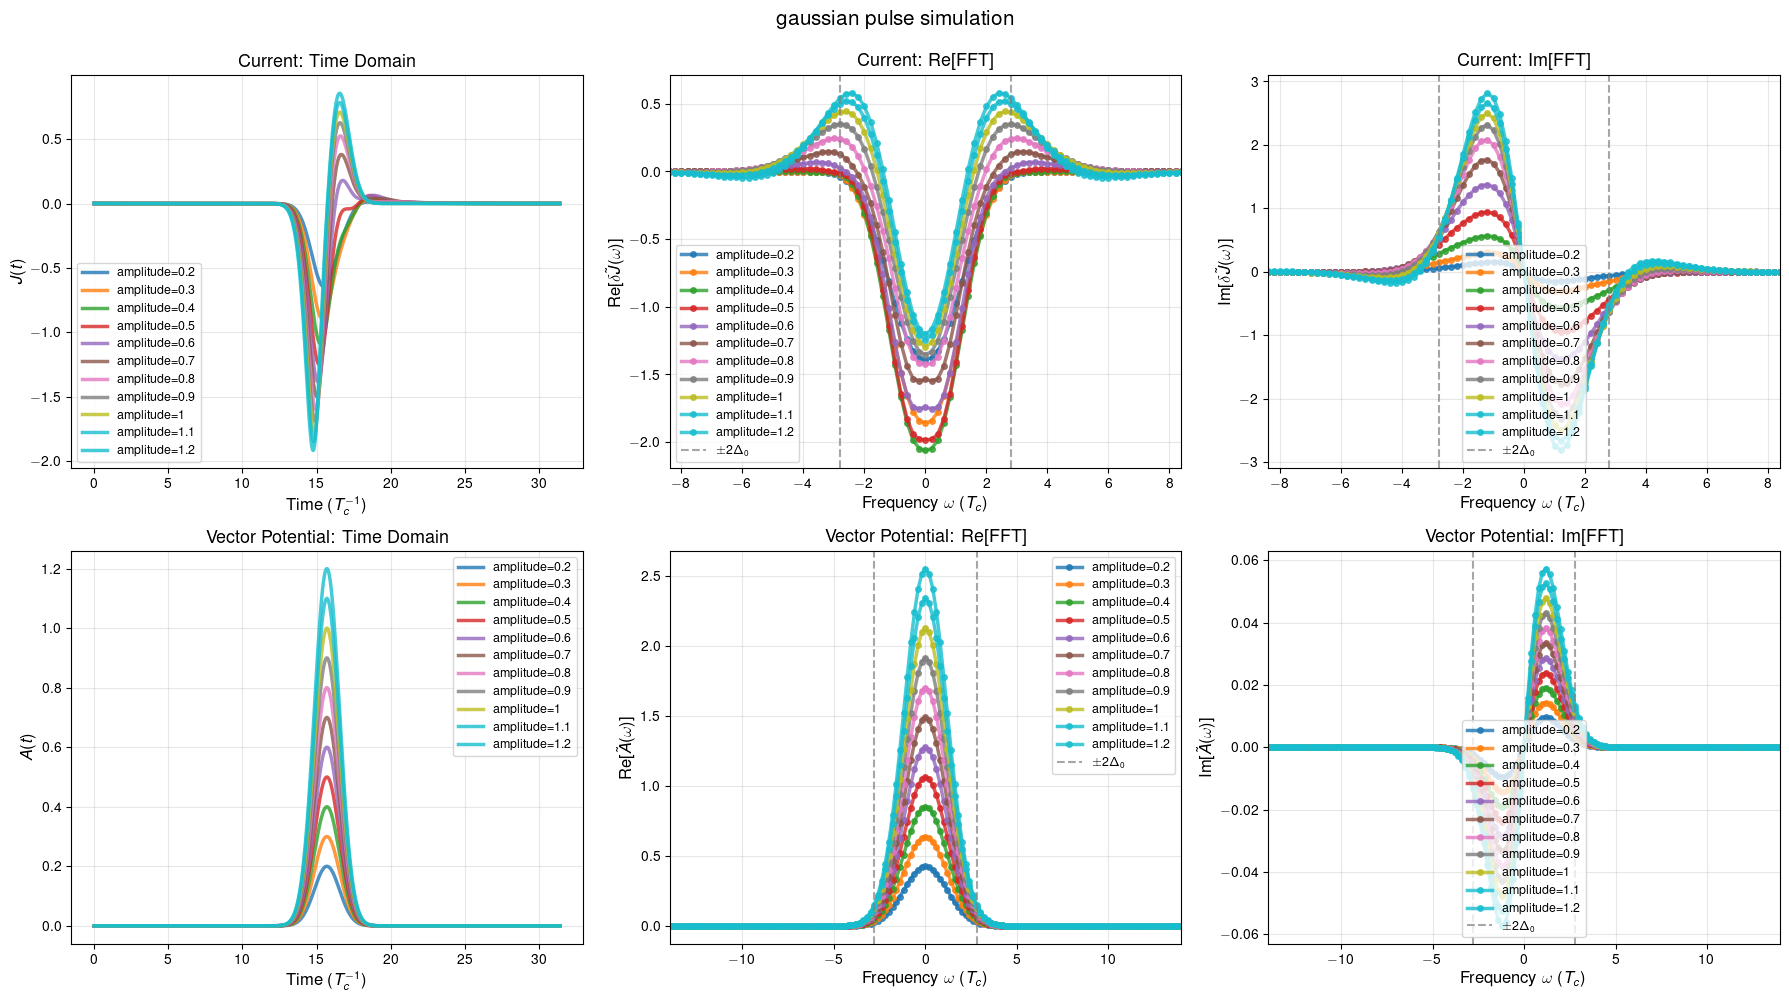

In [ ]:
amplitude_index = 3
width_index = 4

job_list_width = np.arange(1,100,20) + amplitude_index
job_list_amplitude = np.arange(1,12,1) + 20 * (width_index)

print(job_list_width)
print(job_list_amplitude)
As, gaps, fig, axes = da.plot_current_evolution_multi_jobs('1782221209', job_indices = job_list_amplitude,save_plot=False)


#! check that it goes to zero up to the precision

## Comparing with Quasi-static evolution -- ultra long pulses 


Parameter validation (evolution vs equilibrium):
  eta: 0.2 ✓
  temperature: 0.5 ✓
  critical_temperature: 1 ✓
  Total time duration: 0.000000 ✓

Loading equilibrium sweep data...
Loaded equilibrium data: 20 points from A=0.000 to 0.800

Job 0: Plotting 3000 points
  Gap range: [1.264, 1.402]
  Current range: [-0.588, -0.033]
  A range: [9.582e-03, 2.000e-01]
  Time range: [0.000, 62.811]


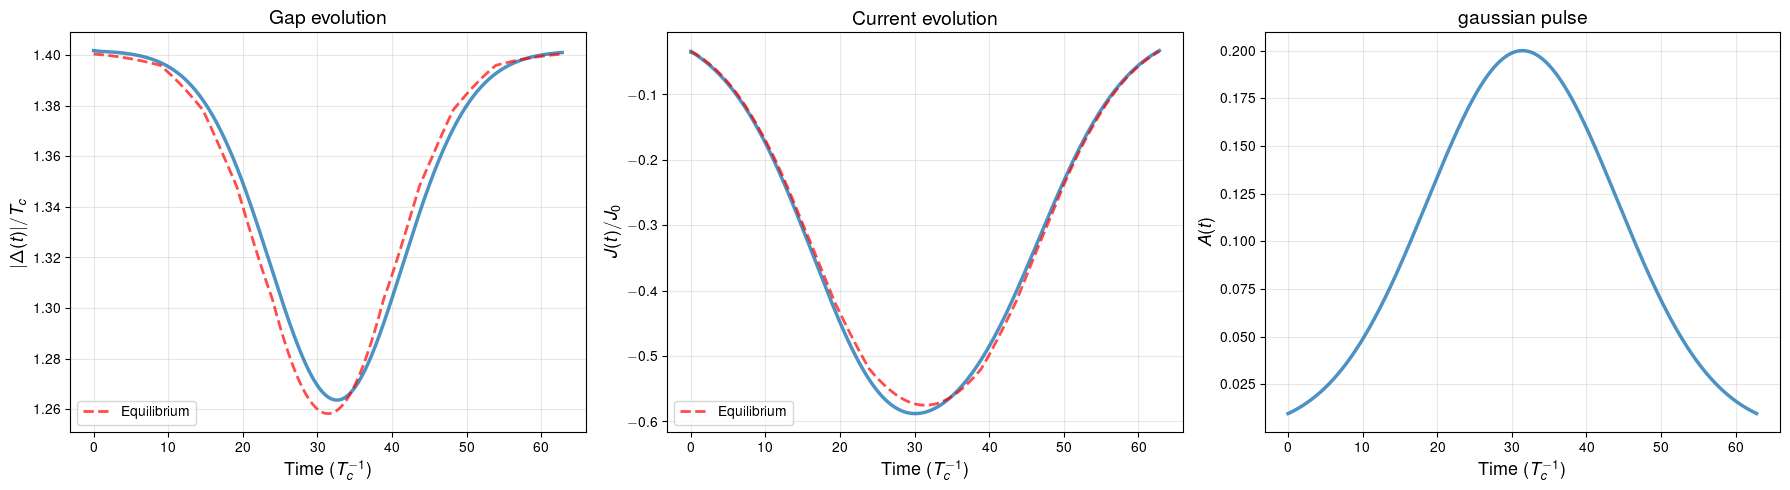

In [ ]:
evolution_timestamp = '1782715691'
evolution_job_index = 0
equilibrium_timestamp = '1782220134'
da.plot_gap_current_combined(
      timestamp=evolution_timestamp,           # Your time evolution run
      job_index=evolution_job_index,                      # Specific job to plot
      equilibrium_timestamp=equilibrium_timestamp,  # Your equilibrium sweep run
      n_average=100,                    # Average last 100 timesteps for equilibrium
      save_plot=False,
      markers = False
      #times_external = jons_time_pts,
      #
)

In [ ]:
gaps_external = jons_gaps[evolution_job_index],
      #currents_external = jons_total_current[evolution_job_index],
      #A_external = jons_vector_potentials[evolution_job_index],
      labels_external = 'Quasi-equilibrium',
      align_pulses = True              # Save to Figures/
  )


In [ ]:
evolution_timestamp = '1782221046'
evolution_job_index = 5
equilibrium_timestamp = '1782220134'
da.plot_gap_current_combined(
      timestamp=evolution_timestamp,           # Your time evolution run
      job_index=evolution_job_index,                      # Specific job to plot
      equilibrium_timestamp=equilibrium_timestamp,  # Your equilibrium sweep run
      n_average=100,                    # Average last 100 timesteps for equilibrium
      save_plot=True,
      times_external = jons_time_pts,
      gaps_external = jons_gaps[evolution_job_index],
      currents_external = jons_total_current[evolution_job_index],
      A_external = jons_vector_potentials[evolution_job_index],
      labels_external = 'Quasi-equilibrium',
      align_pulses = True              # Save to Figures/
  )



Parameter validation (evolution vs equilibrium):
  eta: 0.2 ✓
  temperature: 0.5 ✓
  critical_temperature: 1 ✓
  Total time duration: 0.000000 ✓

Loading equilibrium sweep data...
Loaded equilibrium data: 20 points from A=0.000 to 0.800

Job 5: Plotting 1500 points
  Gap range: [1.141, 1.402]
  Current range: [-0.865, 0.011]
  A range: [1.056e-39, 3.000e-01]
  Time range: [0.000, 31.395]

Pulse alignment enabled:
  Reference pulse maximum at t = 15.687
  External dataset 'Quasi-equilibrium': t_max = 10.025, shift = +5.662
Plot saved to: /home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/Figures/gap_current_combined_1782221046_job5_eq1782220134.png



Parameter validation (evolution vs equilibrium):
  eta: 0.2 ✓
  temperature: 0.5 ✓
  critical_temperature: 1 ✓
  Total time duration: 0.000000 ✓

Loading equilibrium sweep data...
Loaded equilibrium data: 20 points from A=0.000 to 0.800

Job 9: Plotting 1500 points
  Gap range: [1.222, 1.402]
  Current range: [-0.943, 0.037]
  A range: [5.867e-298, 2.999e-01]
  Time range: [0.000, 31.395]

Pulse alignment enabled:
  Reference pulse maximum at t = 15.687
  External dataset 'Quasi-equilibrium': t_max = 10.025, shift = +5.662


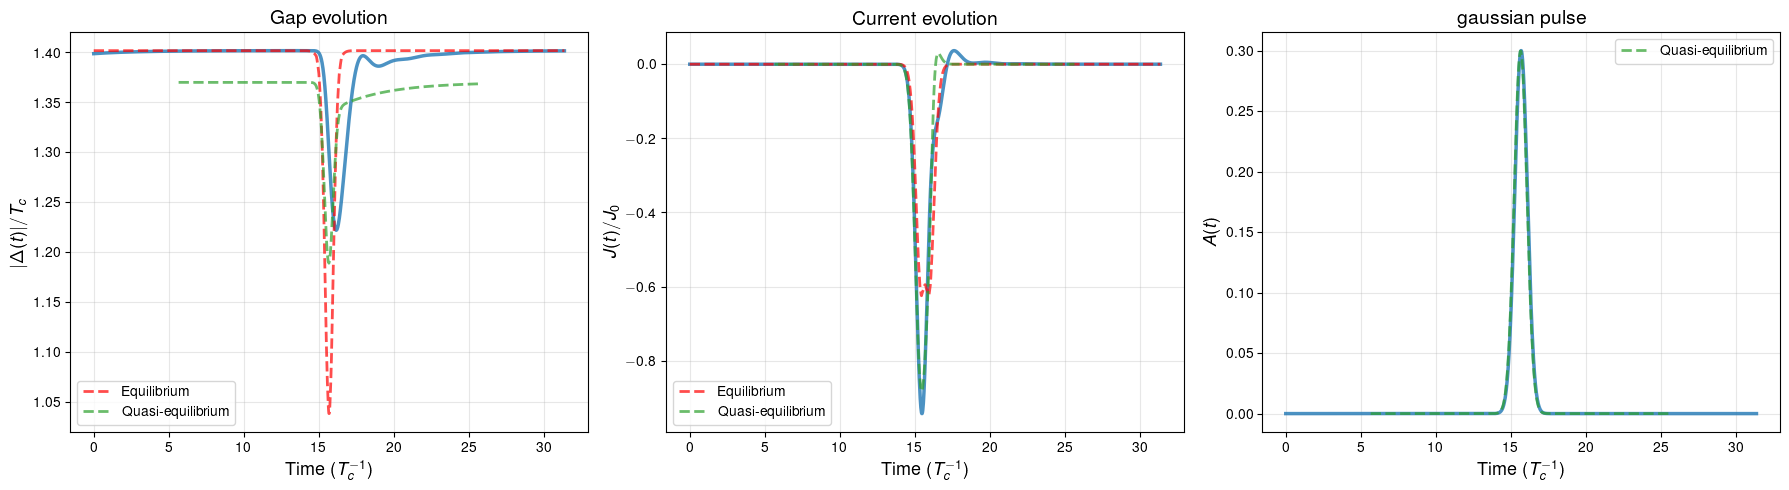

In [ ]:
evolution_timestamp = '1782221046'
evolution_job_index = 9
equilibrium_timestamp = '1782220134'
da.plot_gap_current_combined(
      timestamp=evolution_timestamp,           # Your time evolution run
      job_index=evolution_job_index,                      # Specific job to plot
      equilibrium_timestamp=equilibrium_timestamp,  # Your equilibrium sweep run
      n_average=100,                    # Average last 100 timesteps for equilibrium
      save_plot=False,
      times_external = jons_time_pts,
      gaps_external = jons_gaps[evolution_job_index],
      currents_external = jons_total_current[evolution_job_index],
      A_external = jons_vector_potentials[evolution_job_index],
      labels_external = 'Quasi-equilibrium',
      align_pulses = True              # Save to Figures/
  )


## Driving "Higgs" mode

In [ ]:
higgs_ts = '1782221209'
#da.identify_sweep_parameters(higgs_ts) #1782658064

[ 2 12 22 32 42]
[11 12 13 14 15 16 17 18 19]

Plotting gap evolution for 4 jobs from timestamp: 1782221209

Loading job 21...


Loading job 41...
Loading job 61...
Loading job 81...

Detected varying parameters:
  field_params.FWHM: [np.float64(0.575), np.float64(1.05), np.float64(1.525), np.float64(2.0)]


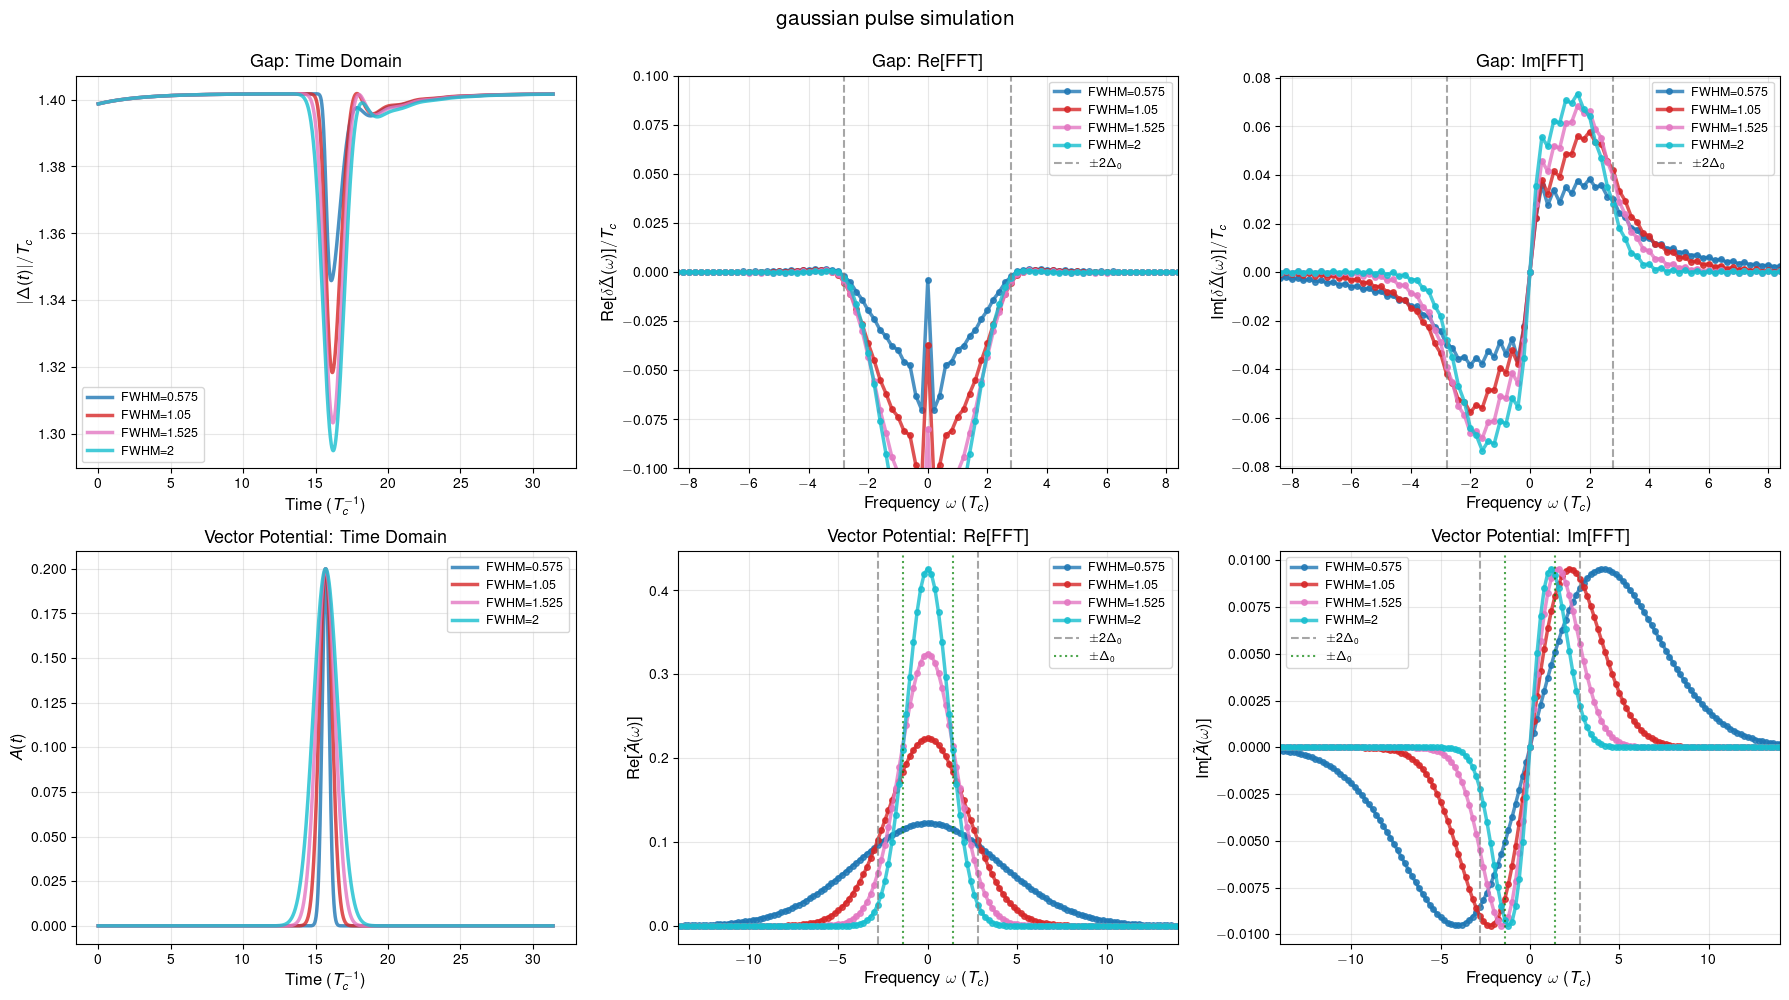

In [ ]:
amplitude_index = 1
width_index = 1

job_list_width = np.arange(1,50,10) + amplitude_index
job_list_amplitude = np.arange(1,10,1) + 10 * (width_index)

job_indices = np.linspace(1, 4, 4).astype(int) * 20 + 1

print(job_list_width)
print(job_list_amplitude)
As, gaps, fig, axes = da.plot_gap_evolution_multi_jobs(higgs_ts, job_indices = job_indices,save_plot=False, ylim_gap_omega_re = (-0.1, 0.1))



Extracting gap response (timestamp=1782221209):
  Equilibrium gap: Δ₀ = 1.398715
  Processing 4 jobs: [np.int64(21), np.int64(41), np.int64(61), np.int64(81)]
  Job 21: Stored 59 frequency points
  Job 41: Stored 36 frequency points
  Job 61: Stored 27 frequency points
  Job 81: Stored 21 frequency points
Extracted 143 gap response points
  Frequency range: [0.200, 11.800]



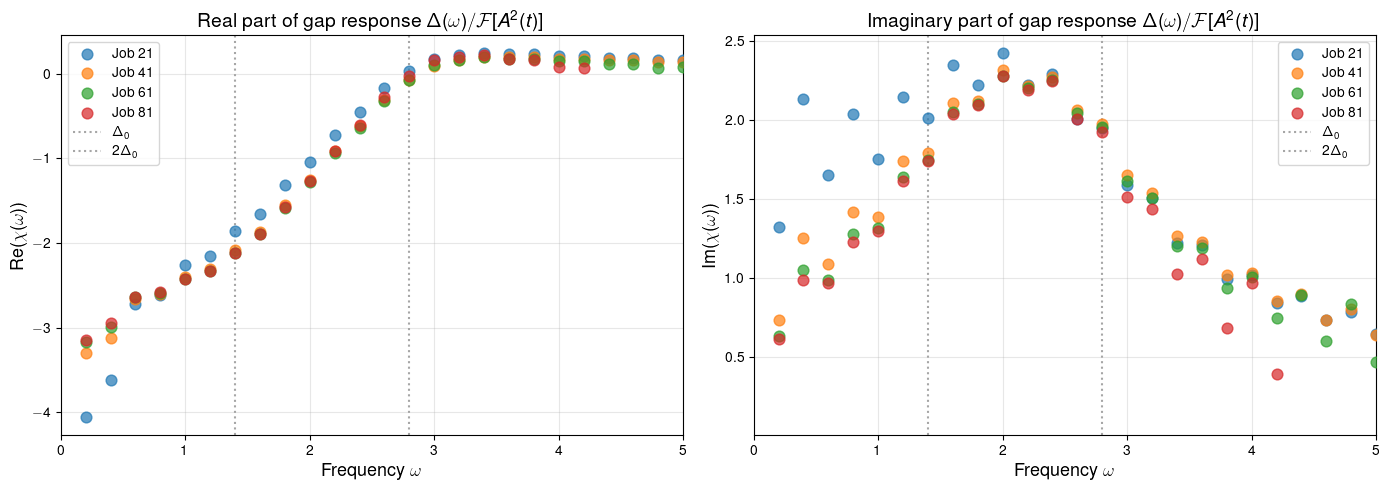

In [ ]:
job_indices = np.linspace(1, 4, 4).astype(int) * 20 + 1

data = da.extract_gap_response(timestamp=higgs_ts,save_plot=False, job_indices = job_indices, threshold = 0.1, xlim = (0,5))

## Vector potential drive with quasi-particle tracking

In [ ]:
drive_timestamp = '1782657651'
#da.identify_sweep_parameters(drive_timestamp)

[ 4 14 24 34 44]
[11 12 13 14 15 16 17 18 19]

Plotting gap evolution for 5 jobs from timestamp: 1782657651

Loading job 4...
Loading job 14...
Loading job 24...
Loading job 34...
Loading job 44...

Detected varying parameters:
  field_params.FWHM: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/filip/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


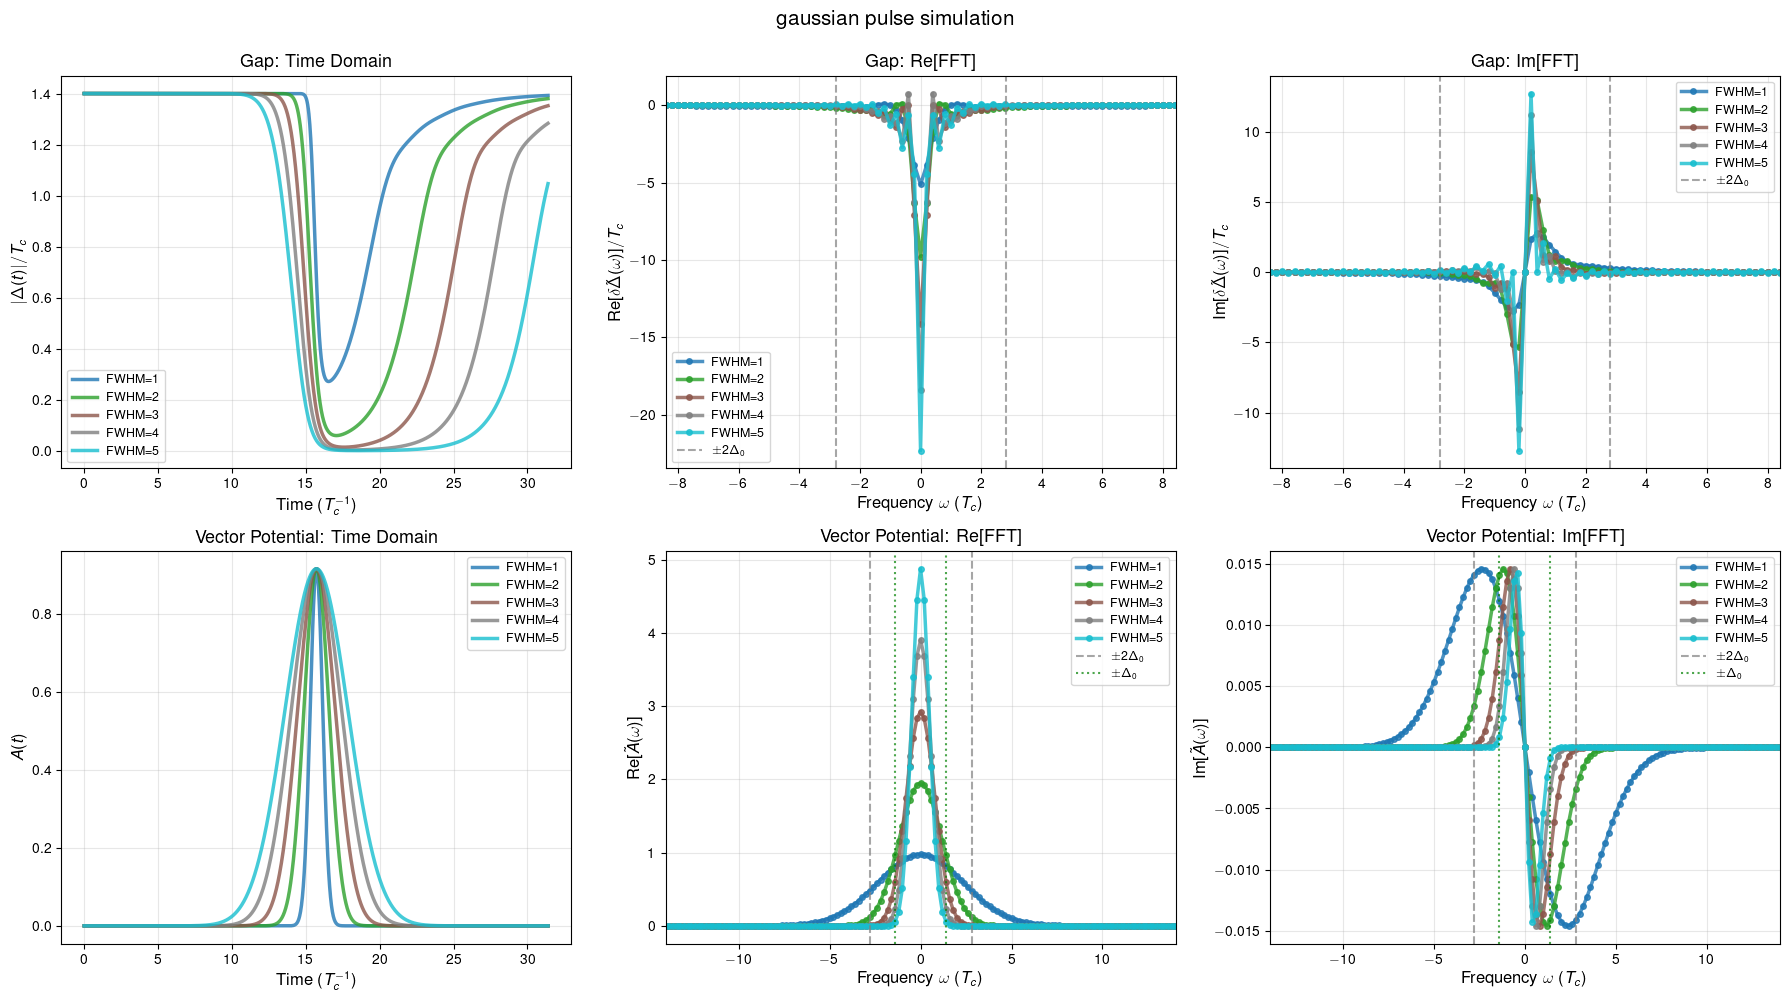

In [ ]:
amplitude_index = 3
width_index = 1

job_list_width = np.arange(1,50,10) + amplitude_index
job_list_amplitude = np.arange(1,10,1) + 10 * (width_index)

print(job_list_width)
print(job_list_amplitude)
As, gaps, fig, axes = da.plot_gap_evolution_multi_jobs(drive_timestamp, job_indices = job_list_width,save_plot=False)



Plotting current evolution for 5 jobs from timestamp: 1782657651

Loading job 4...
Loading job 14...
Loading job 24...
Loading job 34...
Loading job 44...

Detected varying parameters:
  field_params.FWHM: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


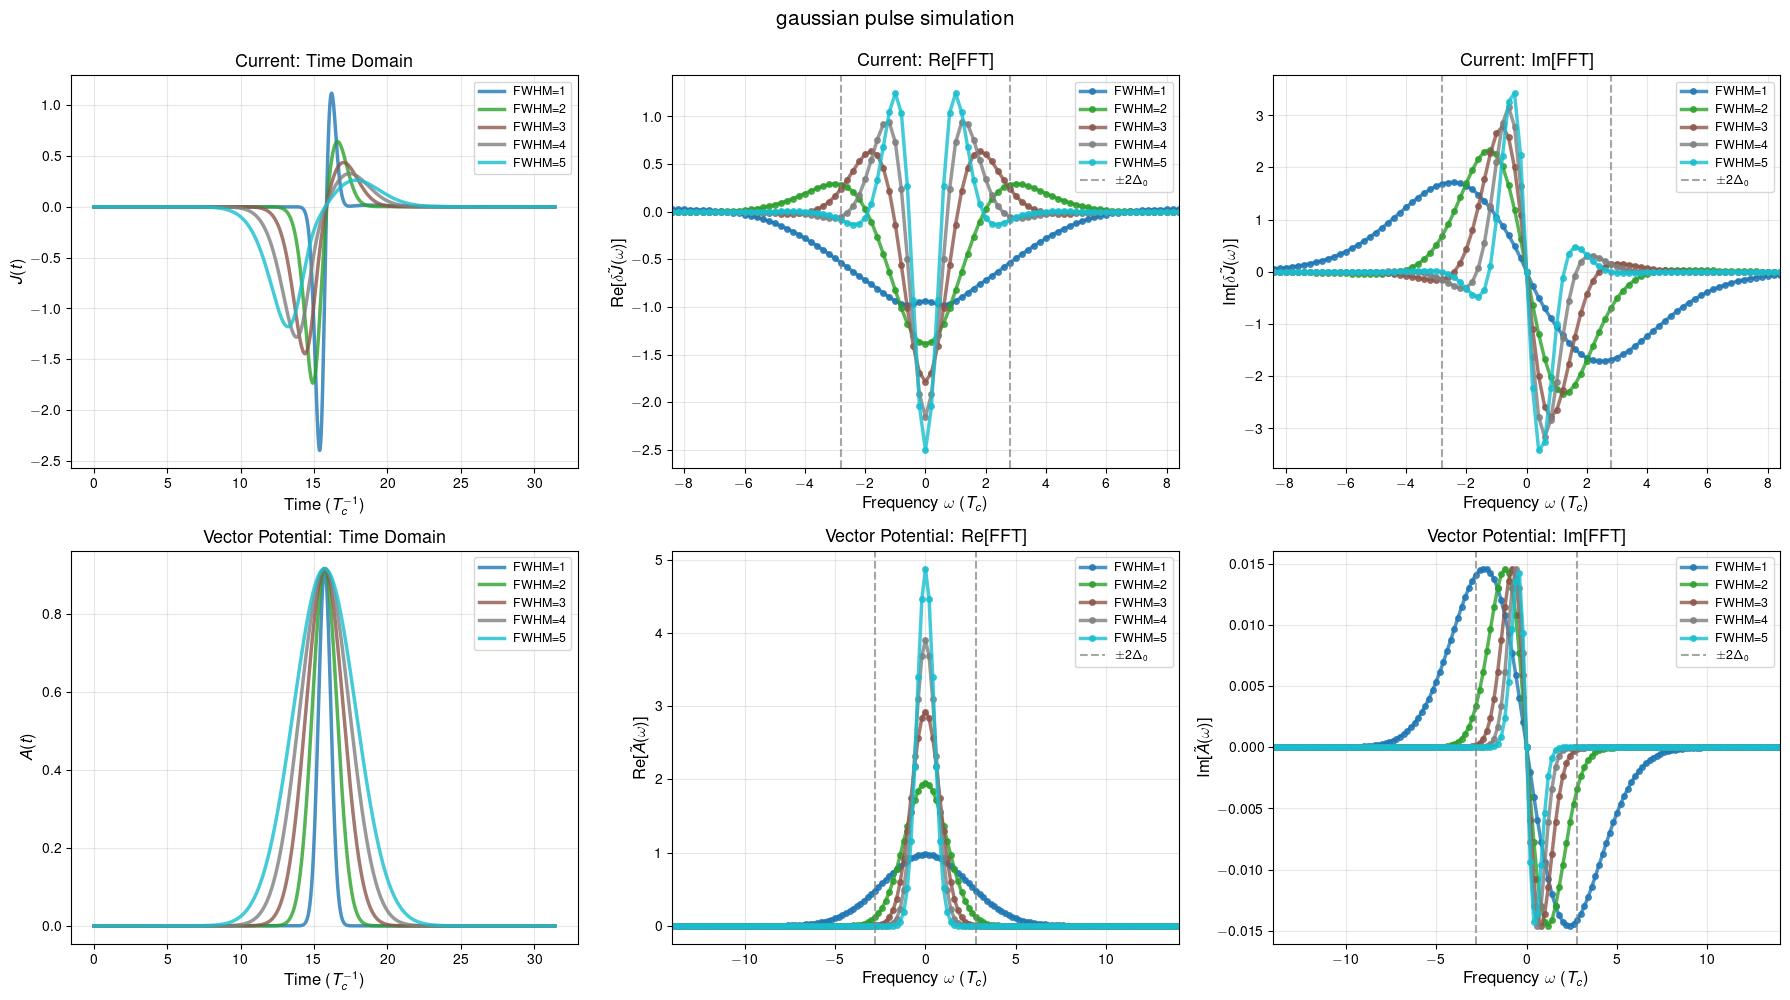

In [ ]:
As, js, fig, axes = da.plot_current_evolution_multi_jobs(drive_timestamp,save_plot=False, job_indices = job_list_width)


In [ ]:
result = da.plot_energy_time_representation_slider(
      timestamp=drive_timestamp,
      job_index=44,
      green_function_type='gk',
      #pauli_components=(2, 3),
      xlim=(-10, 10),
      plot_eq=True
  )



Alignment info: N_t=1501, spectrum_offset=750 timesteps, track_every_n=20, snapshot_offset=37 snapshots



Interactive Energy-Time Plot
  Function type: g^gk
  Pauli components: (2, 3)
  Total time slices: 75
  Time range: [0.0000, 30.9970]



# Incoming current pulses

In [ ]:
evolution_timestamp = '1782916909'
evolution_job_index = 10


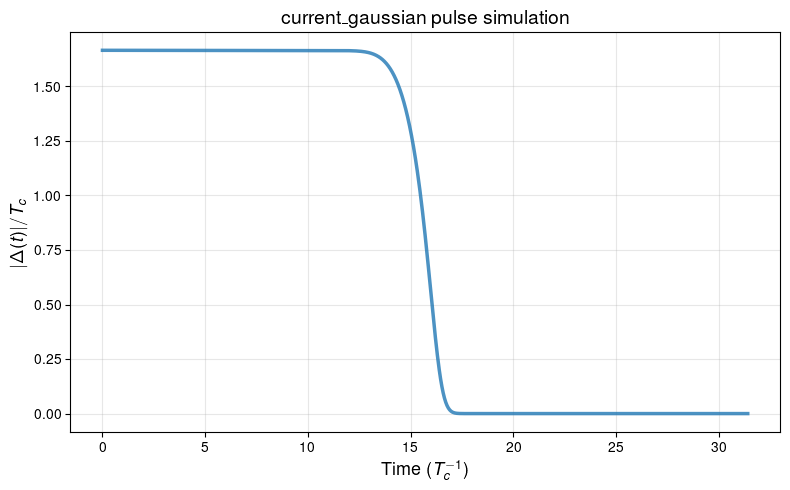

In [ ]:

# Plot gap evolution for this job
da.plot_gap(evolution_timestamp, evolution_job_index, save_plot=False)


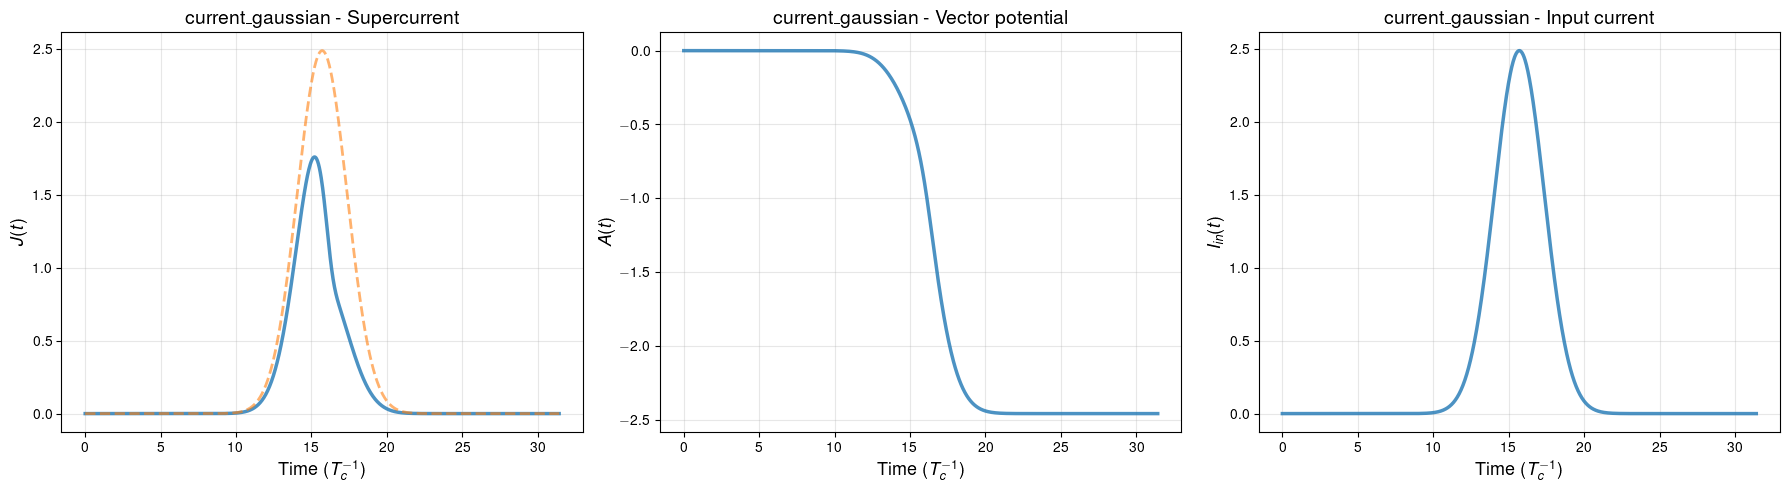

In [ ]:
# Plot current evolution for this job
da.plot_current(evolution_timestamp, evolution_job_index, save_plot=False, print_final = False)


## Transmitivity plot

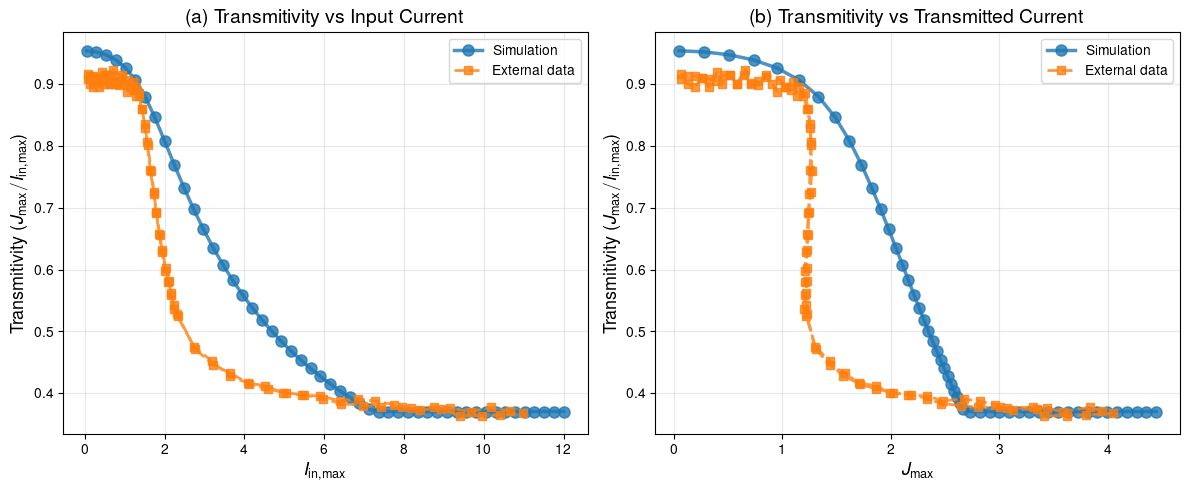

In [ ]:
#print(sc_data_x)
#print(sc_data_y)
#1782916909 eta = 0.1 -- constant current quench 
#1782918450 eta = 0.2 

da.extract_transmitivity(['1782918450'], ext_data_x= np.abs(sc_data_x)/35, ext_data_y = sc_data_y, save_plot = False)

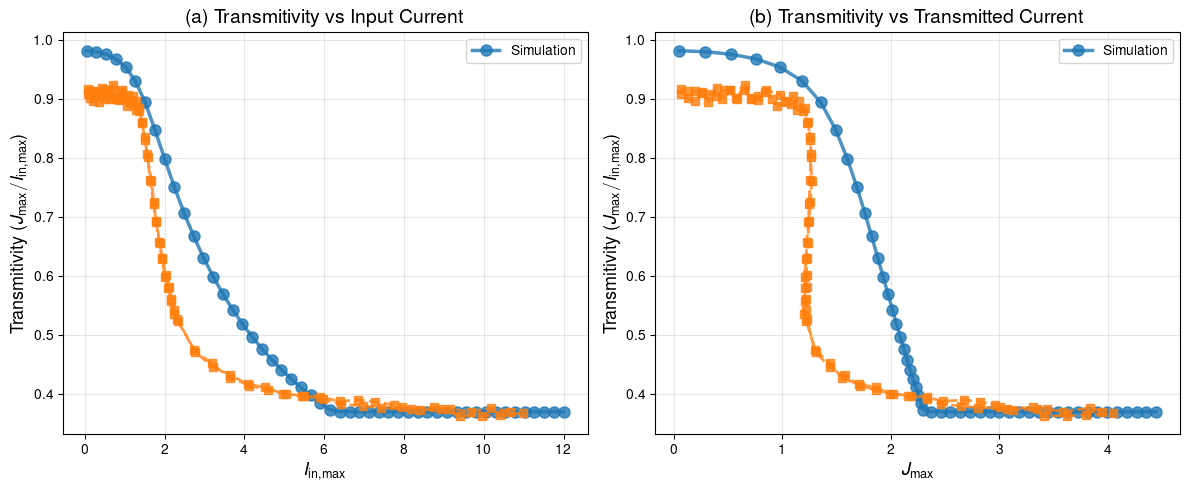

In [ ]:
da.extract_transmitivity(['1782916909'], ext_data_x= np.abs(sc_data_x)/35, ext_data_y = sc_data_y, save_plot = False)

## comparing two $\eta$ results

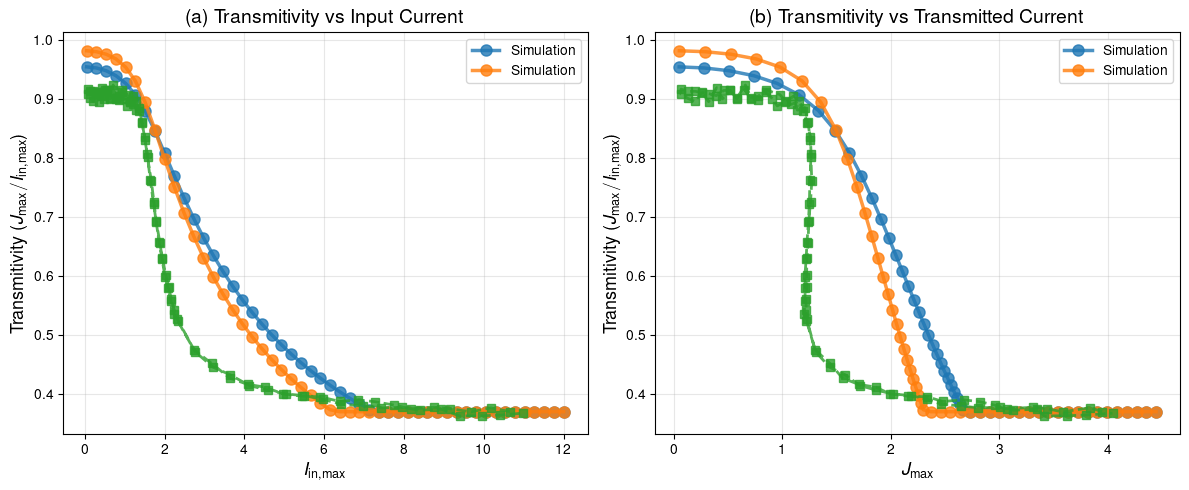

In [ ]:
da.extract_transmitivity(['1782918450', '1782916909'], ext_data_x= np.abs(sc_data_x)/35, ext_data_y = sc_data_y, save_plot = False)

### Transmitivity for shorter pulses

In [ ]:
da.identify_sweep_parameters('1782913098')


IDENTIFYING SWEEP PARAMETERS FOR TIMESTAMP: 1782913098

Loading 100 jobs...

Found 2 varying parameter(s):

1. field_params.FWHM
   Values: [1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718, 1.9477874452256718

{'varying_parameters': [('field_params.FWHM',
   [1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.9477874452256718,
    1.947787445225

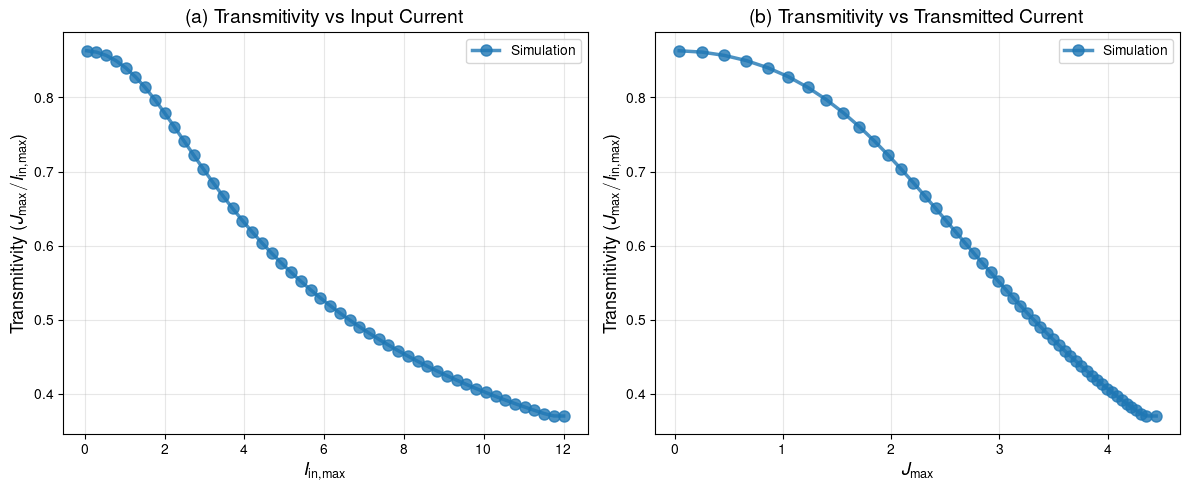

In [ ]:
job_indices = np.arange(0, 50, 1)
da.extract_transmitivity('1782913098', save_plot = False, job_index_list = job_indices)

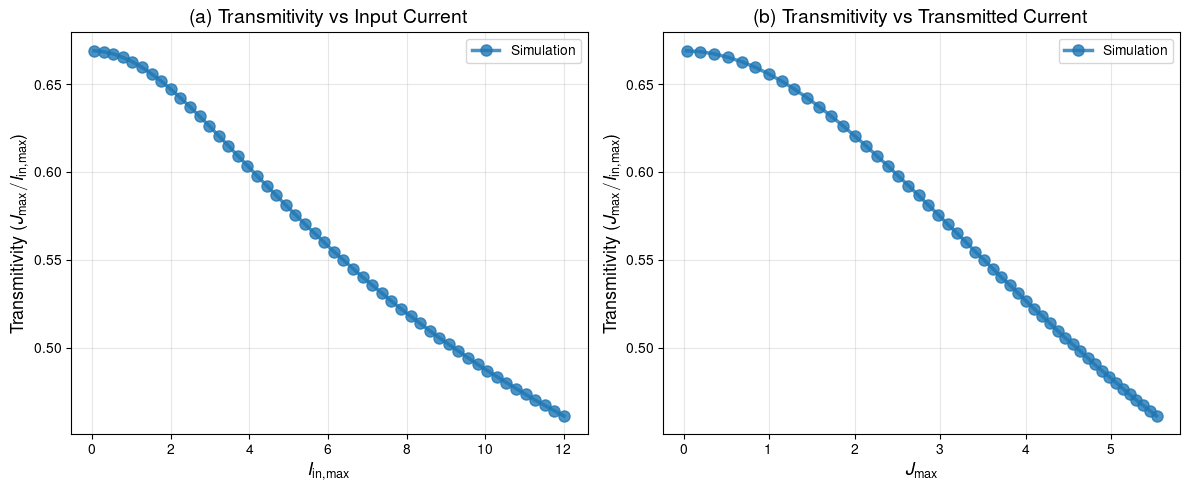

In [ ]:
job_indices = np.arange(0, 50, 1) + 50
da.extract_transmitivity('1782913098', save_plot = False, job_index_list = job_indices)

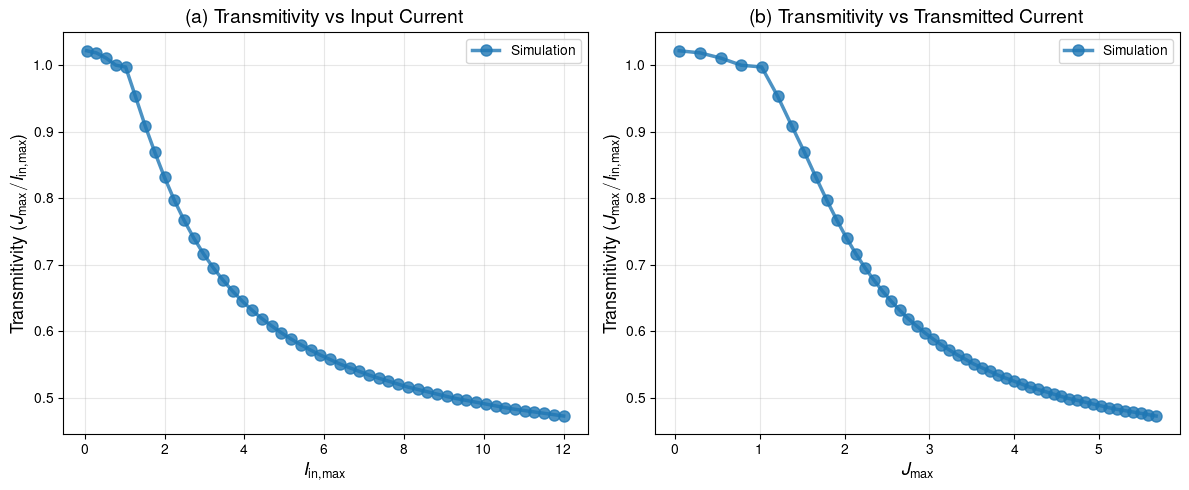

In [ ]:
da.extract_transmitivity(['1782844332'], save_plot = False)